# 00. Разведочный анализ выбранного среза

Это первый шаг проекта по дедупликации SKU. Здесь мы не обучаем модель и не принимаем решение о склейке товаров, а проверяем качество выбранного среза: какие названия товаров, бренды, веса и фасовки доступны, где есть пропуски и какие примеры стоит смотреть внимательнее.

На выходе получаем таблицы, графики и короткие выводы для следующего этапа: поиска пар товаров для сравнения в `01_candidate_generation.ipynb`.

## Оглавление

- [0. Локальные параметры запуска](#0-локальные-параметры-запуска)
- [1. Подготовка окружения](#1-подготовка-окружения)
- [2. Почтовый архив и подтверждение интереса к MPStats и электронной коммерции](#2-почтовый-архив-и-подтверждение-интереса-к-mpstatse-commerce)
- [3. Выбор среза для анализа](#3-выбор-среза-для-анализа)
- [4. Подключение к кубу и выбор категории](#4-подключение-к-кубу-и-выбор-категории)
- [5. Загрузка строк выбранной категории из DuckDB](#5-загрузка-строк-выбранной-категории-из-duckdb)
- [6. Вспомогательные функции анализа](#6-вспомогательные-функции-анализа)
- [7. Базовая статистика и пропуски](#7-базовая-статистика-и-пропуски)
- [8. Заполненность бренда](#8-заполненность-бренда)
- [9. Распределения веса и фасовки](#9-распределения-веса-и-фасовки)
- [10. Аномалии веса и фасовки](#10-аномалии-веса-и-фасовки)
- [11. Информативность названий товаров](#11-информативность-названий-товаров)
- [12. Частотный анализ слов в названиях](#12-частотный-анализ-слов-в-названиях)
- [13. Бренд, фасовка и числовые связи](#13-бренд-фасовка-и-числовые-связи)
- [14. Примеры товаров, похожих на дубли, без модели](#14-примеры-товаров-похожих-на-дубли-без-модели)
- [15. Примеры похожих, но разных товаров без модели](#15-примеры-похожих-но-разных-товаров-без-модели)
- [16. Итоговые выводы](#16-итоговые-выводы)

## Как читать ноутбук

Сначала задаются локальные параметры: выбранная категория, путь к DuckDB и, при необходимости, путь к почтовому архиву. Затем ноутбук читает таблицу `mpstats_products`, проверяет ключевые признаки для дедупликации SKU и заканчивает примерами пар, которые помогут подготовить разметку и сравнение моделей.


## 0. Локальные параметры запуска

В следующей ячейке с кодом задаются все параметры запуска. `MY_CATEGORY_RUN` означает выбранный срез для анализа, `MY_DUCKDB_PATH` — путь к локальному кубу, а остальные настройки ограничивают количество примеров и управляют необязательным анализом почтового архива.

Параметры оставлены в ноутбуке специально: на защите видно, какой срез анализировался и какие ограничения использовались, без скрытых настроек во внешнем `.env`.


In [1]:
# === MY notebook settings ===
# Какой research-run анализировать: "sauces", "coconut_oil" или "soap".
MY_CATEGORY_RUN = 'sauces'

# Если None, notebook ищет mpstats.duckdb через настройки приложения/корень проекта.
MY_DUCKDB_PATH = None

# Лимиты только для читаемых примеров в EDA, не для загрузки данных.
MY_MAX_EXAMPLE_PAIRS = 15
MY_MAX_HARD_NEGATIVE_EXAMPLES = 10

# Вес выше этого значения считаем подозрительным в диагностических таблицах.
MY_MAX_REASONABLE_WEIGHT_KG = 40.0

# Опциональный EDA почтового архива: доказывает, что часто приходят запросы по MPStats/ecom.
# Оставьте False для обычного SKU EDA. Для анализа укажите путь к .pst/.ost и включите True.
MY_RUN_MAIL_ARCHIVE_EDA = True
MY_MAIL_ARCHIVE_PATH = "/Users/exoldoff/Desktop/backup.pst"  # пример: "/Users/me/Downloads/archive.pst"
MY_MAIL_MAX_MESSAGES = None  # можно поставить 5000 для быстрого smoke-run
MY_MAIL_INCLUDE_BODY = True  # False считает только subject/sender/headers и работает быстрее
MY_MAIL_EXPORT_DIR = "artifacts/reports/mail_archive_eda"

# Группы ключевых слов. Всё, что связано с MPStats, маркетплейсами и электронной коммерцией,
# считаем одним рабочим контекстом, без деления на отдельные темы.
MY_MAIL_TOPIC_PATTERNS = {
    "MPStats и электронная коммерция": [
        r"\bmp\s*stats?\b",
        r"\bmpstats\b",
        r"мп\s*статс",
        r"мпстатс",
        r"мп\s*статистик",
        r"\be[-\s]?com(?:merce)?\b",
        r"\becommerce\b",
        r"\bеком\b",
        r"\bе-ком\b",
        r"электронн\w*\s+коммерц",
        r"маркетплейс",
        r"\bmarketplace\b",
        r"\bozon\b",
        r"\bwb\b",
        r"wildberries",
        r"яндекс\s*маркет",
        r"yandex\s*market",
    ],
    "Аналитический контекст": [
        r"аналитик",
        r"статистик",
        r"выгрузк",
        r"отч[её]т",
        r"дашборд",
        r"продаж",
        r"\bsku\b",
        r"категори",
    ],
}
MY_MAIL_TARGET_TOPIC_GROUPS = ["MPStats и электронная коммерция"]

# Эти люди считаются частью MPStats-контекста, если они указаны отправителем
# или присутствуют в получателях/копии письма.
MY_MAIL_ECOM_PERSON_PATTERNS = [
    r"вадим\s+пепеляев",
    r"vadim\s+pepelyaev",
]


## 1. Подготовка окружения

Этот блок находит корень репозитория, подключает существующие модули проекта и настраивает отображение таблиц и графиков. Так ноутбук использует ту же структуру проекта, что и основной код, но не дублирует её внутри ячеек.

Подключение к DuckDB выполняется через `duckdb_connection(..., read_only=True)`: это режим только для чтения, поэтому анализ не меняет локальную базу.


In [2]:
from __future__ import annotations

from collections import Counter
from itertools import combinations
import math
from pathlib import Path
import re
import sys
from typing import Iterable

import numpy as np
import pandas as pd
from IPython.display import Markdown, display

try:
    import matplotlib.pyplot as plt
    import seaborn as sns
except ImportError as exc:
    raise ImportError(
        "Для визуального EDA нужны matplotlib и seaborn. "
        "Установите их в окружение ноутбука, например: "
        "python3 -m pip install matplotlib seaborn"
    ) from exc


def find_project_root(start: Path) -> Path:
    '''Ищет корень репозитория по файлам, которые уже есть в проекте.'''
    for candidate in [start, *start.parents]:
        if (candidate / "AGENTS.md").exists() and (candidate / "mpstats_app").exists():
            return candidate
    raise FileNotFoundError("Не удалось найти корень проекта: нет AGENTS.md и mpstats_app/.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from mpstats_app.config import AppSettings
from mpstats_app.utils import quote_duckdb_name
from pipeline.repositories.sql_repository import duckdb_connection, table_exists
from pipeline.services.sales_filter_service import DEFAULT_SALES_FILTER_GROUP_COLUMNS, DEFAULT_SALES_MIN_QUANTILE, DEFAULT_SALES_MIN_UNITS, filter_sales_by_quantile
from research.dedup import resolve_category_run, resolve_run_paths

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 140)
sns.set_theme(style="whitegrid", context="notebook")

print(f"PROJECT_ROOT: {PROJECT_ROOT}")


PROJECT_ROOT: /Users/exoldoff/.codex/worktrees/13ef/mpstats


## 2. Почтовый архив и подтверждение интереса к MPStats и электронной коммерции

Этот необязательный блок нужен как дополнительное обоснование задачи: он считает, как часто в почте встречаются рабочие запросы про MPStats, маркетплейсы и электронную коммерцию. Для самой дедупликации SKU он не обязателен, но помогает показать практический контекст проекта.

Для запуска нужно установить зависимости из `requirements.txt`: модуль `pypff` приходит из pip-пакета `libpff-python`. Затем укажите путь к PST/OST-архиву в `MY_MAIL_ARCHIVE_PATH` и включите `MY_RUN_MAIL_ARCHIVE_EDA = True`. Если флаг выключен, блок аккуратно пропускается и не мешает основному анализу товаров.

Тела писем не сохраняются в CSV: они используются только для поиска ключевых слов. В выгрузки попадают агрегаты, динамика по месяцам, домены отправителей и короткие фрагменты тем писем.

In [3]:
MAIL_ARCHIVE_PATH = Path(MY_MAIL_ARCHIVE_PATH).expanduser() if MY_MAIL_ARCHIVE_PATH else None
MAIL_EXPORT_DIR = (PROJECT_ROOT / MY_MAIL_EXPORT_DIR).resolve()

mail_df = pd.DataFrame()
matched_mail_df = pd.DataFrame()
mail_archive_metadata: dict[str, object] = {
    "enabled": bool(MY_RUN_MAIL_ARCHIVE_EDA),
    "archive_path": str(MAIL_ARCHIVE_PATH) if MAIL_ARCHIVE_PATH else None,
}

HTML_TAG_RE = re.compile(r"<[^>]+>")
EMAIL_RE = re.compile(r"[A-Z0-9._%+-]+@([A-Z0-9.-]+\.[A-Z]{2,})", flags=re.IGNORECASE)


def decode_pff_value(value: object) -> str:
    """Приводит строковые/bytes поля pypff к обычному тексту."""
    if value is None:
        return ""
    if isinstance(value, bytes):
        for encoding in ("utf-8", "utf-16", "cp1251", "latin1"):
            try:
                return value.decode(encoding).replace("\x00", " ").strip()
            except UnicodeDecodeError:
                continue
        return value.decode("utf-8", errors="ignore").replace("\x00", " ").strip()
    return str(value).replace("\x00", " ").strip()


def safe_pff_attr(item: object, attr_names: Iterable[str], default: object = None) -> object:
    """Читает первое доступное pypff-свойство и не падает на битых item."""
    for attr_name in attr_names:
        try:
            value = getattr(item, attr_name)
        except Exception:
            continue
        if callable(value):
            try:
                value = value()
            except Exception:
                continue
        if value not in (None, ""):
            return value
    return default


def first_text(item: object, attr_names: Iterable[str]) -> str:
    return decode_pff_value(safe_pff_attr(item, attr_names, default=""))


def clean_message_text(value: object) -> str:
    text = decode_pff_value(value)
    text = HTML_TAG_RE.sub(" ", text)
    return re.sub(r"\s+", " ", text).strip()


def parse_message_datetime(value: object) -> pd.Timestamp:
    if value in (None, ""):
        return pd.NaT
    parsed = pd.to_datetime(value, errors="coerce", utc=True)
    if pd.isna(parsed):
        return pd.NaT
    return parsed.tz_convert(None)


def iter_pff_collection(item: object, collection_attr: str, count_attr: str, getter_attr: str):
    collection = safe_pff_attr(item, [collection_attr])
    if collection is not None:
        try:
            yield from collection
            return
        except TypeError:
            pass
    count = safe_pff_attr(item, [count_attr], default=0) or 0
    try:
        getter = getattr(item, getter_attr)
    except Exception:
        getter = None
    if not callable(getter):
        return
    for index in range(int(count)):
        try:
            yield getter(index)
        except Exception:
            continue


def iter_pff_messages(folder: object, folder_path: tuple[str, ...] = ()): 
    folder_name = first_text(folder, ["name", "display_name"]) or "ROOT"
    current_path = (*folder_path, folder_name)
    for message in iter_pff_collection(folder, "sub_messages", "number_of_sub_messages", "get_sub_message"):
        yield " / ".join(current_path), message
    for subfolder in iter_pff_collection(folder, "sub_folders", "number_of_sub_folders", "get_sub_folder"):
        yield from iter_pff_messages(subfolder, current_path)


def compile_mail_patterns(topic_patterns: dict[str, list[str]]) -> dict[str, list[re.Pattern[str]]]:
    return {
        topic: [re.compile(pattern, flags=re.IGNORECASE | re.UNICODE) for pattern in patterns]
        for topic, patterns in topic_patterns.items()
    }


def match_mail_topics(text: str, compiled_patterns: dict[str, list[re.Pattern[str]]]) -> tuple[list[str], list[str]]:
    topics: list[str] = []
    keywords: list[str] = []
    for topic, patterns in compiled_patterns.items():
        topic_hits = []
        for pattern in patterns:
            topic_hits.extend(match.group(0) for match in pattern.finditer(text))
        if topic_hits:
            topics.append(topic)
            keywords.extend(sorted(set(hit.strip() for hit in topic_hits if hit.strip())))
    return topics, sorted(set(keywords))


def sender_domain(sender_email: str, headers: str, sender_name: str) -> str:
    for value in (sender_email, headers, sender_name):
        match = EMAIL_RE.search(value or "")
        if match:
            return match.group(1).lower()
    return ""


def recipient_text(message: object) -> str:
    """Собирает получателей и копию письма, если pypff отдаёт эти поля."""
    chunks = [
        first_text(message, ["display_to", "to", "receiver_name", "recipients"]),
        first_text(message, ["display_cc", "cc"]),
        first_text(message, ["display_bcc", "bcc"]),
    ]
    for recipient in iter_pff_collection(message, "recipients", "number_of_recipients", "get_recipient"):
        chunks.extend([
            first_text(recipient, ["name", "display_name", "recipient_name"]),
            first_text(recipient, ["email_address", "smtp_address", "email"]),
        ])
    return "\n".join(chunk for chunk in chunks if chunk)


def match_ecom_people(text: str, patterns: list[re.Pattern[str]]) -> list[str]:
    """Ищет людей, чьё участие в письме относит его к MPStats-контексту."""
    hits: list[str] = []
    for pattern in patterns:
        hits.extend(match.group(0).strip() for match in pattern.finditer(text or ""))
    return sorted(set(hit for hit in hits if hit))


def extract_message_record(folder_path: str, message: object, compiled_patterns: dict[str, list[re.Pattern[str]]], compiled_person_patterns: list[re.Pattern[str]]) -> dict[str, object]:
    subject = first_text(message, ["subject", "name", "conversation_topic"])
    sender_name = first_text(message, ["sender_name", "sender", "sender_display_name"])
    sender_email = first_text(message, ["sender_email_address", "sender_email", "sender_smtp_address"])
    headers = first_text(message, ["transport_headers", "headers"])
    recipients = recipient_text(message)
    message_date = parse_message_datetime(
        safe_pff_attr(message, ["delivery_time", "client_submit_time", "creation_time", "modification_time"])
    )

    body = ""
    if MY_MAIL_INCLUDE_BODY:
        body = clean_message_text(safe_pff_attr(message, ["plain_text_body", "text_body", "body", "html_body"]))
    topic_text = "\n".join(part for part in [subject, sender_name, sender_email, headers, body] if part)
    participant_text = "\n".join(part for part in [sender_name, sender_email, headers, recipients] if part)
    matched_topics, matched_keywords = match_mail_topics(topic_text, compiled_patterns)
    person_hits = match_ecom_people(participant_text, compiled_person_patterns)
    if person_hits:
        ecom_topic = MY_MAIL_TARGET_TOPIC_GROUPS[0]
        if ecom_topic not in matched_topics:
            matched_topics.append(ecom_topic)
        matched_keywords = sorted(set([*matched_keywords, *person_hits]))
    target_topic_set = set(MY_MAIL_TARGET_TOPIC_GROUPS)

    return {
        "message_date": message_date,
        "folder_path": folder_path,
        "sender_name": sender_name,
        "sender_email": sender_email,
        "sender_domain": sender_domain(sender_email, headers, sender_name),
        "recipients": recipients,
        "subject": subject,
        "matched_topics": matched_topics,
        "matched_keywords": matched_keywords,
        "has_target_topic": bool(target_topic_set.intersection(matched_topics)),
        "body_chars_scanned": len(body),
    }


if not MY_RUN_MAIL_ARCHIVE_EDA:
    display(Markdown(
        "Почтовый анализ выключен. Чтобы посчитать запросы по MPStats и электронной коммерции, "
        "укажите `MY_MAIL_ARCHIVE_PATH` в первой code-ячейке и поставьте "
        "`MY_RUN_MAIL_ARCHIVE_EDA = True`."
    ))
elif MAIL_ARCHIVE_PATH is None or not MAIL_ARCHIVE_PATH.exists():
    raise FileNotFoundError(
        "PST/OST-архив не найден. Укажите существующий путь в MY_MAIL_ARCHIVE_PATH."
    )
else:
    try:
        import pypff
    except ImportError as exc:
        raise ImportError(
            "Не найден pypff/libpff. Установите Python-зависимости: "
            "python3 -m pip install -r requirements.txt. "
            "Если удобнее сначала экспортировать архив, можно использовать pffexport/readpst, "
            "а этот блок оставить для прямого чтения .pst/.ost."
        ) from exc

    if hasattr(pypff, "check_file_signature") and not pypff.check_file_signature(str(MAIL_ARCHIVE_PATH)):
        raise ValueError(f"Файл не похож на PST/OST/PAB архив libpff: {MAIL_ARCHIVE_PATH}")

    compiled_mail_patterns = compile_mail_patterns(MY_MAIL_TOPIC_PATTERNS)
    compiled_person_patterns = [re.compile(pattern, flags=re.IGNORECASE | re.UNICODE) for pattern in MY_MAIL_ECOM_PERSON_PATTERNS]
    pff_file = pypff.open(str(MAIL_ARCHIVE_PATH))
    mail_archive_metadata.update({
        "pypff_version": pypff.get_version() if hasattr(pypff, "get_version") else "unknown",
        "archive_size_bytes": safe_pff_attr(pff_file, ["size"], default=None),
        "content_type": safe_pff_attr(pff_file, ["content_type"], default=None),
        "encryption_type": safe_pff_attr(pff_file, ["encryption_type"], default=None),
    })
    try:
        root_folder = safe_pff_attr(pff_file, ["root_folder"])
        if root_folder is None:
            raise RuntimeError("В архиве не найден root_folder.")
        records = []
        max_messages = None if MY_MAIL_MAX_MESSAGES in (None, 0) else int(MY_MAIL_MAX_MESSAGES)
        for folder_path, message in iter_pff_messages(root_folder):
            records.append(extract_message_record(folder_path, message, compiled_mail_patterns, compiled_person_patterns))
            if max_messages is not None and len(records) >= max_messages:
                break
    finally:
        pff_file.close()

    mail_df = pd.DataFrame(records)
    if not mail_df.empty:
        mail_df["message_date"] = pd.to_datetime(mail_df["message_date"], errors="coerce", utc=True).dt.tz_convert(None)
        matched_mail_df = mail_df.loc[mail_df["has_target_topic"]].copy()

    print(f"Всего прочитано писем: {len(mail_df):,}")
    print(f"Писем по MPStats и электронной коммерции: {len(matched_mail_df):,}")
    display(pd.DataFrame([mail_archive_metadata]))


Всего прочитано писем: 6,094
Писем по MPStats и электронной коммерции: 383


,enabled,archive_path,pypff_version,archive_size_bytes,content_type,encryption_type
0,True,/Users/exoldoff/Desktop/backup.pst,20231205,4282917888,112,1


,metric,value
0,Всего писем в срезе,6094
1,Писем по MPStats и электронной коммерции,383
2,Доля писем по MPStats и электронной коммерции,6.3%
3,Уникальных доменов-отправителей в этих письмах,3
4,Первое письмо,2025-06-10
5,Последнее письмо,2026-06-05


,месяц,все_письма,письма_MPStats_и_электронная_коммерция,доля_таких_писем,среднее_за_3_месяца
0,2025-06-01,369,4,0.010840,4.000000
1,2025-07-01,604,0,0.000000,2.000000
2,2025-08-01,938,1,0.001066,1.666667
3,2025-09-01,591,6,0.010152,2.333333
4,2025-10-01,555,8,0.014414,5.000000
5,2025-11-01,399,27,0.067669,13.666667
6,2025-12-01,501,96,0.191617,43.666667
7,2026-01-01,418,50,0.119617,57.666667
8,2026-02-01,388,12,0.030928,52.666667
9,2026-03-01,538,77,0.143123,46.333333


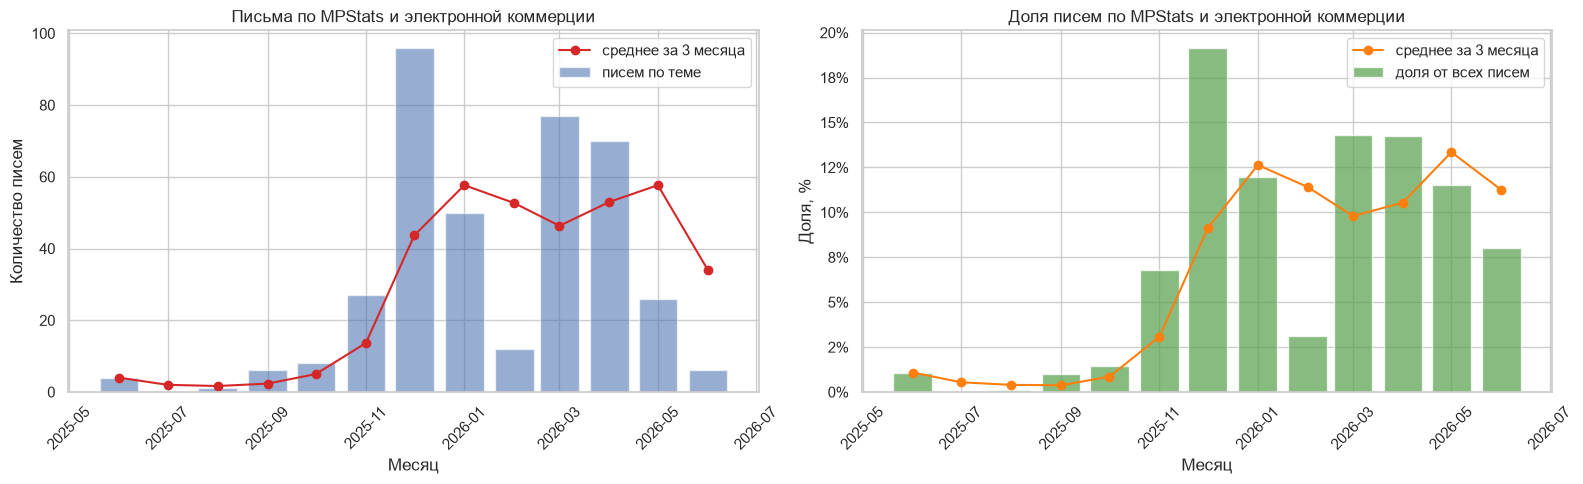

,домен_отправителя,писем_по_теме
0,unknown,207
1,rusagromaslo.com,128
2,rusagrogroup.ru,30
3,mbnrs.ru,18


,дата_письма,домен_отправителя,папка,тема_письма,найденные_темы,найденные_слова
696,2026-06-04 14:50:18.164520,rusagromaslo.com,ROOT / Корневой уровень файла данных Outlook / Inbox,RE: Данные сахар,"[MPStats и электронная коммерция, Аналитический контекст]","[MP Stats, Ozon, Выгрузк, маркетплейс, продаж, электронной коммерц]"
1638,2026-06-04 14:49:33.964000,,ROOT / Корневой уровень файла данных Outlook / Sent Items,RE: Данные сахар,"[MPStats и электронная коммерция, Аналитический контекст]","[MP Stats, Ozon, Выгрузк, маркетплейс, продаж, электронной коммерц]"
1634,2026-06-04 06:10:31.442000,,ROOT / Корневой уровень файла данных Outlook / Sent Items,RE: Данные сахар,"[MPStats и электронная коммерция, Аналитический контекст]","[MP Stats, Ozon, маркетплейс, продаж, электронной коммерц]"
1628,2026-06-02 09:32:12.355000,,ROOT / Корневой уровень файла данных Outlook / Sent Items,RE: Данные Иком,"[MPStats и электронная коммерция, Аналитический контекст]","[Категори, дашборд, категори, отчет, электронной коммерц]"
692,2026-06-02 09:27:15.938712,rusagromaslo.com,ROOT / Корневой уровень файла данных Outlook / Inbox,RE: Данные Иком,"[MPStats и электронная коммерция, Аналитический контекст]","[Категори, дашборд, категори, отчет, электронной коммерц]"
691,2026-06-02 09:13:12.115533,rusagromaslo.com,ROOT / Корневой уровень файла данных Outlook / Inbox,RE: Данные сахар,"[MPStats и электронная коммерция, Аналитический контекст]","[MP Stats, Ozon, маркетплейс, продаж, электронной коммерц]"
1621,2026-05-28 14:31:20.599000,,ROOT / Корневой уровень файла данных Outlook / Sent Items,RE: MPstats МПРА,"[MPStats и электронная коммерция, Аналитический контекст]","[MPstats, Ozon, МПстатс, аналитик, выгрузк, категори, продаж]"
1003,2026-05-28 13:55:00.000000,,ROOT / Корневой уровень файла данных Outlook / Sent Items,Accepted: МПСТАТС - МПРА,[MPStats и электронная коммерция],[МПСТАТС]
460,2026-05-28 13:44:58.317839,rusagromaslo.com,ROOT / Корневой уровень файла данных Outlook / Deleted Items,МПСТАТС - МПРА,[MPStats и электронная коммерция],[МПСТАТС]
1002,2026-05-28 09:24:00.000000,,ROOT / Корневой уровень файла данных Outlook / Sent Items,Accepted: МПСТАТС - МПРА,[MPStats и электронная коммерция],[МПСТАТС]


Почтовые таблицы сохранены: /Users/exoldoff/.codex/worktrees/13ef/mpstats/artifacts/reports/mail_archive_eda


In [4]:
if mail_df.empty:
    display(Markdown("Нет прочитанных писем для почтового анализа."))
else:
    matched_mail_df = mail_df.loc[mail_df["has_target_topic"]].copy()
    total_messages = len(mail_df)
    ecom_messages = len(matched_mail_df)
    ecom_share = ecom_messages / total_messages if total_messages else 0.0
    date_min = mail_df["message_date"].min()
    date_max = mail_df["message_date"].max()

    mail_summary = pd.DataFrame([
        {"metric": "Всего писем в срезе", "value": total_messages},
        {"metric": "Писем по MPStats и электронной коммерции", "value": ecom_messages},
        {"metric": "Доля писем по MPStats и электронной коммерции", "value": f"{ecom_share:.1%}"},
        {"metric": "Уникальных доменов-отправителей в этих письмах", "value": matched_mail_df["sender_domain"].replace("", np.nan).nunique()},
        {"metric": "Первое письмо", "value": date_min.date().isoformat() if pd.notna(date_min) else "нет даты"},
        {"metric": "Последнее письмо", "value": date_max.date().isoformat() if pd.notna(date_max) else "нет даты"},
    ])
    display(mail_summary)

    dated_all = mail_df.dropna(subset=["message_date"]).copy()
    dated_matched = matched_mail_df.dropna(subset=["message_date"]).copy()
    monthly_stats = pd.DataFrame()
    if not dated_all.empty:
        dated_all["month"] = dated_all["message_date"].dt.to_period("M").dt.to_timestamp()
        dated_matched["month"] = dated_matched["message_date"].dt.to_period("M").dt.to_timestamp()
        all_monthly = dated_all.groupby("month").size().rename("all_messages")
        ecom_monthly = dated_matched.groupby("month").size().rename("ecom_messages")
        monthly_stats = pd.concat([all_monthly, ecom_monthly], axis=1).fillna(0).astype(int)
        month_index = pd.date_range(monthly_stats.index.min(), monthly_stats.index.max(), freq="MS")
        monthly_stats = monthly_stats.reindex(month_index, fill_value=0).rename_axis("month").reset_index()
        monthly_stats["ecom_share"] = np.where(
            monthly_stats["all_messages"] > 0,
            monthly_stats["ecom_messages"] / monthly_stats["all_messages"],
            0.0,
        )
        monthly_stats["ecom_messages_3m_avg"] = monthly_stats["ecom_messages"].rolling(3, min_periods=1).mean()
        monthly_view = monthly_stats.rename(
            columns={
                "month": "месяц",
                "all_messages": "все_письма",
                "ecom_messages": "письма_MPStats_и_электронная_коммерция",
                "ecom_share": "доля_таких_писем",
                "ecom_messages_3m_avg": "среднее_за_3_месяца",
            }
        )
        display(monthly_view.tail(24))

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    if not monthly_stats.empty:
        axes[0].bar(monthly_stats["month"], monthly_stats["ecom_messages"], width=24, alpha=0.58, label="писем по теме")
        axes[0].plot(monthly_stats["month"], monthly_stats["ecom_messages_3m_avg"], color="tab:red", marker="o", label="среднее за 3 месяца")
        axes[0].set_title("Письма по MPStats и электронной коммерции")
        axes[0].set_xlabel("Месяц")
        axes[0].set_ylabel("Количество писем")
        axes[0].legend()
        axes[0].tick_params(axis="x", rotation=45)

        share_percent = monthly_stats["ecom_share"] * 100
        axes[1].bar(monthly_stats["month"], share_percent, width=24, color="#59A14F", alpha=0.72, label="доля от всех писем")
        axes[1].plot(monthly_stats["month"], share_percent.rolling(3, min_periods=1).mean(), color="tab:orange", marker="o", label="среднее за 3 месяца")
        axes[1].set_title("Доля писем по MPStats и электронной коммерции")
        axes[1].set_xlabel("Месяц")
        axes[1].set_ylabel("Доля, %")
        axes[1].yaxis.set_major_formatter(lambda x, _: f"{x:.0f}%")
        axes[1].legend()
        axes[1].tick_params(axis="x", rotation=45)
    else:
        for ax in axes:
            ax.axis("off")
            ax.text(0.5, 0.5, "Нет дат для динамики", ha="center", va="center")
    plt.tight_layout()
    plt.show()

    top_senders = (
        matched_mail_df.assign(sender_domain=matched_mail_df["sender_domain"].replace("", "unknown"))
        .groupby("sender_domain")
        .size()
        .rename("ecom_messages")
        .sort_values(ascending=False)
        .head(20)
        .reset_index()
        .rename(columns={"sender_domain": "домен_отправителя", "ecom_messages": "писем_по_теме"})
    )
    display(top_senders)

    sample_columns = ["message_date", "sender_domain", "folder_path", "subject", "matched_topics", "matched_keywords"]
    sample_view = matched_mail_df.sort_values("message_date", ascending=False, na_position="last")[sample_columns].head(30)
    sample_view = sample_view.rename(
        columns={
            "message_date": "дата_письма",
            "sender_domain": "домен_отправителя",
            "folder_path": "папка",
            "subject": "тема_письма",
            "matched_topics": "найденные_темы",
            "matched_keywords": "найденные_слова",
        }
    )
    display(sample_view)

    MAIL_EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    mail_summary.to_csv(MAIL_EXPORT_DIR / "mail_archive_summary.csv", index=False)
    if not monthly_stats.empty:
        monthly_stats.to_csv(MAIL_EXPORT_DIR / "mail_archive_monthly_stats.csv", index=False)
    matched_mail_df[sample_columns].to_csv(MAIL_EXPORT_DIR / "mail_archive_matched_messages.csv", index=False)
    print(f"Почтовые таблицы сохранены: {MAIL_EXPORT_DIR}")

### Комментарий по результатам

Почтовый архив подтверждает интерес к MPStats и электронной коммерции: заметные пики приходятся на конец 2025 и весну 2026 года. 

## 3. Выбор среза для анализа

Здесь `MY_CATEGORY_RUN` переводится в конкретный проект и категорию внутри куба. В тексте это выбранный срез: например, соусы, кокосовое масло или мыло.

Код сначала проверяет известные названия категории, а затем ищет ближайшее совпадение в данных. Это нужно, чтобы анализ не ломался из-за формы единственного или множественного числа в названии категории.


In [5]:
CATEGORY_RUN = resolve_category_run(MY_CATEGORY_RUN)
RUN_PATHS = resolve_run_paths(PROJECT_ROOT, CATEGORY_RUN)
TARGET_CATEGORY = CATEGORY_RUN.display_name
CATEGORY_ALIASES = list(CATEGORY_RUN.category_aliases)
PROJECT_NAME = CATEGORY_RUN.project_name
PRODUCTS_TABLE = "mpstats_products"
SALES_MIN_QUANTILE = DEFAULT_SALES_MIN_QUANTILE
SALES_MIN_UNITS = DEFAULT_SALES_MIN_UNITS
SALES_FILTER_DESCRIPTION = (
    f"min sales {SALES_MIN_UNITS:g}"
    if SALES_MIN_QUANTILE is None
    else f"bottom quantile {SALES_MIN_QUANTILE:.0%}; min sales {SALES_MIN_UNITS:g}"
)

MAX_EXAMPLE_PAIRS = int(MY_MAX_EXAMPLE_PAIRS)
MAX_HARD_NEGATIVE_EXAMPLES = int(MY_MAX_HARD_NEGATIVE_EXAMPLES)
MAX_REASONABLE_WEIGHT_KG = float(MY_MAX_REASONABLE_WEIGHT_KG)


def resolve_duckdb_path(project_root: Path) -> Path:
    '''Возвращает путь к существующему DuckDB-кубу и не создаёт новую БД.'''
    explicit_path = Path(MY_DUCKDB_PATH).expanduser() if MY_DUCKDB_PATH else None
    settings_path = AppSettings.create(project_root=project_root).db_path
    candidates = [explicit_path, settings_path]
    for candidate in candidates:
        if candidate is not None and candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError(
        "DuckDB-куб не найден. Укажите MY_DUCKDB_PATH в первой code-ячейке "
        f"или положите базу по стандартному пути: {settings_path}"
    )


DB_PATH = resolve_duckdb_path(PROJECT_ROOT)
print(f"Выбранный срез: {CATEGORY_RUN.slug} — {TARGET_CATEGORY}; project: {PROJECT_NAME}")
print(f"DuckDB cube: {DB_PATH}")


Выбранный срез: sauces — Соусы; project: Соусы_тест
DuckDB cube: /Users/exoldoff/.codex/worktrees/13ef/mpstats/mpstats.duckdb


### Комментарий по результатам

Для анализа выбран срез соусов и проект `Соусы_тест`. Это фиксирует границу эксперимента: дальше мы проверяем качество данных внутри одной товарной области, чтобы не смешивать разные правила склейки SKU.

## 4. Подключение к кубу и выбор категории

В этом разделе ноутбук подключается к таблице `mpstats_products`, которую наполняет основной конвейер обработки. Мы не читаем исходные CSV заново, потому что для дедупликации важен именно тот слой данных, с которым дальше работает приложение.

Здесь проверяется наличие таблицы, доступных колонок, проектного фильтра и реального значения категории в кубе. Это защищает анализ от запуска на случайном или неполном срезе.


In [6]:

with duckdb_connection(DB_PATH, read_only=True) as con:
    if not table_exists(con, PRODUCTS_TABLE):
        raise RuntimeError(f"В кубе нет таблицы {PRODUCTS_TABLE!r}.")

    columns_df = con.execute(f"PRAGMA table_info({quote_duckdb_name(PRODUCTS_TABLE)})").fetchdf()
    column_names = set(columns_df["name"].astype(str))
    project_filter_sql = ""
    project_filter_params: list[str] = []
    if PROJECT_NAME:
        if "__project_name" not in column_names:
            raise RuntimeError("Для выбранного среза нужен project-фильтр, но в кубе нет __project_name.")
        project_filter_sql = f"WHERE {quote_duckdb_name('__project_name')} = ?"
        project_filter_params.append(PROJECT_NAME)

    categories_df = con.execute(
        f'''
        SELECT
            CAST({quote_duckdb_name("Категория")} AS VARCHAR) AS category,
            COUNT(*) AS rows
        FROM {quote_duckdb_name(PRODUCTS_TABLE)}
        {project_filter_sql}
        GROUP BY 1
        ORDER BY rows DESC
        ''',
        project_filter_params,
    ).fetchdf()

print(f"Колонок в {PRODUCTS_TABLE}: {len(columns_df)}")
display(columns_df[["name", "type"]])

display(categories_df.head(30))


Колонок в mpstats_products: 30


,name,type
0,Дата,VARCHAR
1,Маркетплейс,VARCHAR
2,Категория,VARCHAR
3,Артикул,BIGINT
4,Бренд,VARCHAR
5,SKU,VARCHAR
6,"Продажи, шт",DOUBLE
7,Продавец,VARCHAR
8,"Средняя цена, руб",DOUBLE
9,"Выручка, руб",DOUBLE


,category,rows
0,Соус,9953


In [7]:

def normalize_category_name(value: object) -> str:
    '''Нормализация только для выбора реального имени категории в кубе.'''
    return re.sub(r"\s+", " ", str(value or "").strip().casefold())


def choose_real_category(categories: pd.DataFrame, aliases: list[str]) -> str:
    '''Выбирает категорию из куба: точный alias, затем ближайшее совпадение по символам.'''
    available = categories["category"].dropna().astype(str).tolist()
    normalized_to_original = {normalize_category_name(value): value for value in available}

    for alias in aliases:
        normalized = normalize_category_name(alias)
        if normalized in normalized_to_original:
            return normalized_to_original[normalized]

    # Это не matching товаров, а fallback для имени категории, если в данных оно в единственном числе.
    import difflib

    target = normalize_category_name(aliases[0])
    normalized_values = list(normalized_to_original)
    closest = difflib.get_close_matches(target, normalized_values, n=1, cutoff=0.45)
    if closest:
        return normalized_to_original[closest[0]]
    raise ValueError(f"Не нашёл категорию, похожую на {aliases[0]!r}. Доступно: {available[:20]}")


REAL_CATEGORY = choose_real_category(categories_df, CATEGORY_ALIASES)
print(f"Запрошено: {TARGET_CATEGORY!r}")
print(f"Реальное значение category в кубе: {REAL_CATEGORY!r}")


Запрошено: 'Соусы'
Реальное значение category в кубе: 'Соус'


## 5. Загрузка строк выбранной категории из DuckDB

Из DuckDB загружаются только колонки, нужные для разведочного анализа: идентификатор товара, название товара, бренд, категория, подкатегория, продажи и признаки веса/фасовки. Так таблица остаётся достаточно лёгкой для просмотра и графиков.

В разных версиях данных название товара может лежать в разных колонках. Здесь мы фиксируем, из какого поля берём название товара, чтобы дальше сравнивать именно смысловые строки, а не служебные идентификаторы.


In [8]:

PREFERRED_COLUMNS = [
    "__project_name",
    "__year",
    "__month",
    "__marketplace_code",
    "__source_type",
    "Дата",
    "Маркетплейс",
    "Категория",
    "Артикул",
    "SKU",
    "Название",
    "Бренд",
    "Подкатегория",
    "Тип",
    "Вес, кг (ед.)",
    "Вес, кг",
    "Вес аномалия",
    "Вес причина",
    "Объем, кг",
    "Объём, кг",
    "Объем, т",
    "Объём, т",
    "Продажи, шт",
    "Средняя цена, руб",
    "Выручка, руб",
    "Цена за кг",
]

available_columns = columns_df["name"].astype(str).tolist()
selected_columns = [column for column in PREFERRED_COLUMNS if column in available_columns]
missing_preferred_columns = [column for column in PREFERRED_COLUMNS if column not in available_columns]
select_sql = ",\n            ".join(quote_duckdb_name(column) for column in selected_columns)
where_clauses = [f"lower(trim(CAST({quote_duckdb_name('Категория')} AS VARCHAR))) = lower(trim(?))"]
query_params: list[object] = [REAL_CATEGORY]
if PROJECT_NAME:
    if "__project_name" not in available_columns:
        raise RuntimeError("Для выбранного среза нужен project-фильтр, но в кубе нет __project_name.")
    where_clauses.append(f"{quote_duckdb_name('__project_name')} = ?")
    query_params.append(PROJECT_NAME)
where_sql = " AND ".join(where_clauses)

with duckdb_connection(DB_PATH, read_only=True) as con:
    df = con.execute(
        f'''
        SELECT
            {select_sql}
        FROM {quote_duckdb_name(PRODUCTS_TABLE)}
        WHERE {where_sql}
        ''',
        query_params,
    ).fetchdf()

rows_before_sales_filter = len(df)
df = filter_sales_by_quantile(
    df,
    sales_column="Продажи, шт",
    quantile=SALES_MIN_QUANTILE,
    min_sales=SALES_MIN_UNITS,
    group_columns=DEFAULT_SALES_FILTER_GROUP_COLUMNS,
).reset_index(drop=True)

if df.empty:
    raise RuntimeError(f"Срез выбранной категории {CATEGORY_RUN.slug!r} пустой после sales-фильтра: {PROJECT_NAME!r} / {REAL_CATEGORY!r}.")

print(f"Строк после sales-фильтра: {len(df):,} из {rows_before_sales_filter:,} ({SALES_FILTER_DESCRIPTION})")
print("Недоступные optional-колонки:", missing_preferred_columns)
display(df.head(10))


Строк после sales-фильтра: 9,953 из 9,953 (min sales 15)
Недоступные optional-колонки: ['Название', 'Вес аномалия', 'Вес причина', 'Объем, кг', 'Объём, кг', 'Объём, т']


,__project_name,__year,__month,__marketplace_code,__source_type,Дата,Маркетплейс,Категория,Артикул,SKU,Бренд,Подкатегория,Тип,"Вес, кг (ед.)","Вес, кг","Объем, т","Продажи, шт","Средняя цена, руб","Выручка, руб",Цена за кг
0,Соусы_тест,2026,3,oz,category,01.03.2026,Ozon,Соус,2228180086,"Truffle Chef Айоли с трюфелем, 180 г",truffle chef,экзотические,None,0.180,0.180,0.006120,34.0,630.24,21428.0,3501.333333
1,Соусы_тест,2026,3,oz,category,01.03.2026,Ozon,Соус,3574604987,"Перечная паста острая, в стеклянной банке 550 гр.",tat,экзотические,None,0.550,0.550,0.020900,38.0,239.55,9103.0,435.545455
2,Соусы_тест,2026,3,oz,category,01.03.2026,Ozon,Соус,921908857,Соус Унаги Yamura 250мл,yamura,экзотические,None,0.250,0.250,0.088000,352.0,206.02,72518.0,824.080000
3,Соусы_тест,2026,3,oz,category,01.03.2026,Ozon,Соус,2545040309,"Темный соевый соус HADAY Superior / Signature, 1,75 л",haday,соевые,None,1.750,1.750,0.045500,26.0,896.54,23310.0,512.308571
4,Соусы_тест,2026,3,oz,category,01.03.2026,Ozon,Соус,2294061058,"Соусы Calve, ассорти 7 шт (Тартар, Сливочно-чесночный, Сырный, Медово-горчичный, Сырный Цезарь, с лесными грибами, американский бургер) ...",calve,горчица,None,0.230,0.230,0.006210,27.0,929.33,25092.0,4040.565217
5,Соусы_тест,2026,3,oz,category,01.03.2026,Ozon,Соус,1755088601,"ВИАНГ соевый соус ""Премиум"" 500 мл, 3 штуки",вианг,соевые,None,0.500,1.500,0.051000,34.0,627.76,21344.0,418.506667
6,Соусы_тест,2026,3,oz,category,01.03.2026,Ozon,Соус,1624562304,"Cоевый соус натуральный без сахара японский, 1л, MARUKIN",marukin,соевые,None,1.000,1.000,0.057000,57.0,755.65,43072.0,755.650000
7,Соусы_тест,2026,3,oz,category,01.03.2026,Ozon,Соус,1713052785,"Соус Кисло-сладкий, Чим-Чим Hot Asia, 297 г",чим-чим,экзотические,None,0.297,0.297,0.035046,118.0,205.12,24204.0,690.639731
8,Соусы_тест,2026,3,oz,category,01.03.2026,Ozon,Соус,3405107113,Уксус рисовый выдержанный Shuita 420мл,None,уксус,None,0.420,0.420,0.009660,23.0,404.22,9297.0,962.428571
9,Соусы_тест,2026,3,oz,category,01.03.2026,Ozon,Соус,2228253087,"Низкокалорийный соус без сахара Барбекю 270г, Атлас Вкусов",атлас вкусов,томатные,None,0.270,0.270,0.549450,2035.0,207.00,421241.0,766.666667


### Комментарий по результатам

После фильтра продаж осталось 9 953 строки, то есть текущий срез не был дополнительно урезан. В данных уже есть название товара, артикул, бренд, подкатегория, продажи, выручка, вес единицы и общий вес — этого достаточно для первого этапа дедупликации SKU.

## 6. Вспомогательные функции анализа

Функции ниже нужны только для аккуратного подсчёта: привести текст к единому виду, выбрать первую доступную колонку, безопасно обработать числа и пропуски. Они не меняют исходные данные и не заменяют логику основного конвейера.

Это важно для дедупликации SKU: если базовые признаки очищены небрежно, модель сравнения пар будет получать шумные входы и хуже отличать настоящие дубли от похожих товаров.


In [9]:

def first_existing(columns: Iterable[str], frame: pd.DataFrame) -> str | None:
    '''Возвращает первое имя колонки из списка, которое есть в DataFrame.'''
    for column in columns:
        if column in frame.columns:
            return column
    return None


def clean_text_series(series: pd.Series) -> pd.Series:
    '''Строковая очистка для аналитики пропусков и токенов.'''
    return series.astype("string").fillna("").str.replace("\u00a0", " ", regex=False).str.strip()


def non_empty_mask(series: pd.Series) -> pd.Series:
    '''True там, где значение не пустое после trim.'''
    return clean_text_series(series).ne("")


def numeric_series(frame: pd.DataFrame, column: str) -> pd.Series:
    '''Безопасно приводит колонку к числу, поддерживая десятичную запятую.'''
    return pd.to_numeric(
        frame[column]
        .astype("string")
        .str.replace("\u00a0", "", regex=False)
        .str.replace(" ", "", regex=False)
        .str.replace(",", ".", regex=False),
        errors="coerce",
    )


def tokenize_title(value: object) -> list[str]:
    '''Простая токенизация title для частотного анализа, без ML и embeddings.'''
    text = str(value or "").casefold().replace("ё", "е")
    return re.findall(r"[a-zа-я0-9]+", text)


TITLE_COL = first_existing(["Название", "SKU"], df)
SKU_ID_COL = first_existing(["Артикул", "SKU"], df)
BRAND_COL = first_existing(["Бренд", "brand"], df)
CATEGORY_COL = "Категория"

if TITLE_COL is None:
    raise RuntimeError("Не найдена title-колонка: ожидалась `Название` или `SKU`.")

analysis_df = df.copy()
analysis_df["title_text"] = clean_text_series(analysis_df[TITLE_COL])
analysis_df["title_norm"] = analysis_df["title_text"].str.casefold().str.replace("ё", "е", regex=False)
analysis_df["title_char_len"] = analysis_df["title_text"].str.len()
analysis_df["title_tokens"] = analysis_df["title_text"].map(tokenize_title)
analysis_df["title_token_len"] = analysis_df["title_tokens"].map(len)
analysis_df["brand_norm"] = clean_text_series(analysis_df[BRAND_COL]).str.casefold() if BRAND_COL else ""

print(f"Title column: {TITLE_COL}")
print(f"SKU/id column: {SKU_ID_COL}")
print(f"Brand column: {BRAND_COL}")


Title column: SKU
SKU/id column: Артикул
Brand column: Бренд


## 7. Базовая статистика и пропуски

Сначала проверяем размер выбранного среза, число уникальных товаров и заполненность ключевых колонок. Это быстрый ответ на вопрос, достаточно ли данных для дальнейшего поиска дублей.

Тепловая карта ниже показывает долю пропусков по колонкам. Чем темнее ячейка, тем осторожнее нужно использовать этот признак при сравнении товаров.


,value
rows,9953
unique_sku_or_id,6053
unique_title,5738
categories_in_slice,1
projects,1
marketplaces,3
months,2


,column,missing_rows,missing_share
5,Тип,9953,1.000000
4,Подкатегория,258,0.025922
2,Бренд,249,0.025018
0,Артикул,0,0.000000
1,SKU,0,0.000000
3,Категория,0,0.000000
6,"Вес, кг (ед.)",0,0.000000
7,"Вес, кг",0,0.000000
8,"Продажи, шт",0,0.000000
9,"Выручка, руб",0,0.000000


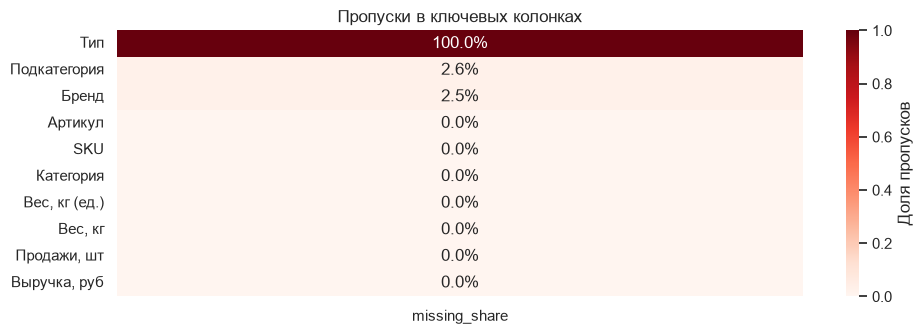

In [10]:

key_columns = [
    column
    for column in [SKU_ID_COL, TITLE_COL, BRAND_COL, "Категория", "Подкатегория", "Тип", "Вес, кг (ед.)", "Вес, кг", "Продажи, шт", "Выручка, руб"]
    if column and column in analysis_df.columns
]

basic_stats = {
    "rows": len(analysis_df),
    "unique_sku_or_id": analysis_df[SKU_ID_COL].nunique(dropna=True) if SKU_ID_COL else np.nan,
    "unique_title": analysis_df["title_norm"].replace("", pd.NA).nunique(dropna=True),
    "categories_in_slice": analysis_df[CATEGORY_COL].nunique(dropna=True),
    "projects": analysis_df["__project_name"].nunique(dropna=True) if "__project_name" in analysis_df else np.nan,
    "marketplaces": analysis_df["Маркетплейс"].nunique(dropna=True) if "Маркетплейс" in analysis_df else np.nan,
    "months": analysis_df[["__year", "__month"]].drop_duplicates().shape[0] if {"__year", "__month"}.issubset(analysis_df.columns) else np.nan,
}

display(pd.DataFrame([basic_stats]).T.rename(columns={0: "value"}))

missing_summary = pd.DataFrame(
    {
        "column": key_columns,
        "missing_rows": [int((~non_empty_mask(analysis_df[column])).sum()) for column in key_columns],
        "missing_share": [float((~non_empty_mask(analysis_df[column])).mean()) for column in key_columns],
    }
).sort_values("missing_share", ascending=False)

display(missing_summary)

plt.figure(figsize=(10, max(3, 0.35 * len(missing_summary))))
sns.heatmap(
    missing_summary.set_index("column")[["missing_share"]],
    annot=True,
    fmt=".1%",
    cmap="Reds",
    cbar_kws={"label": "Доля пропусков"},
)
plt.title("Пропуски в ключевых колонках")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()


### Комментарий по результатам

В срезе 9 953 строки, 6 053 артикула и 5 738 уникальных названий товара за два месяца и три торговые площадки. Пропуски в бренде и подкатегории около 2,5%, а весовые поля заполнены полностью, поэтому данные подходят для следующего шага.

## 8. Заполненность бренда

Бренд помогает отличать один товар от другого, но не должен быть жёстким правилом склейки. В реальных данных бренд может отсутствовать, быть написан по-разному или входить прямо в название товара.

Здесь смотрим долю заполненных строк, самые частые бренды и примеры товаров без бренда, чтобы понять, насколько надёжен этот сигнал при склейке SKU.


,metric,value
0,brand filled rows,9704.000
1,brand empty rows,249.000
2,brand filled share,0.975
3,unique non-empty brands,610.000


,brand,rows
0,tamaki,731
1,aroy-d,374
2,mr.ho,338
3,sen soy,199
4,кинто,178
5,чим-чим,168
6,haday,141
7,takemura,139
8,sanbonsai,122
9,махеевъ,115


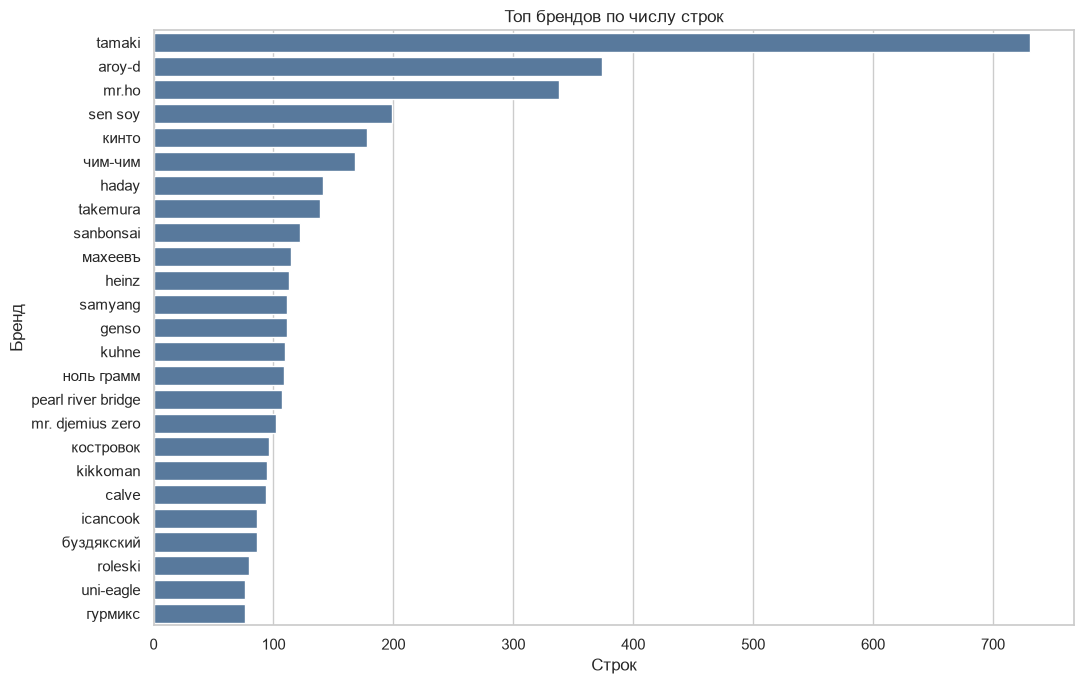

### Примеры строк без бренда

,Артикул,SKU,Категория,Подкатегория,"Вес, кг"
8,3405107113,Уксус рисовый выдержанный Shuita 420мл,Соус,уксус,0.42
19,3307860449,Томатная паста 1600г. 2шт.,Соус,томатная паста,3.20
60,3390584195,Соус устричный JAWS 700 мл,Соус,экзотические,0.70
65,1823558513,"Набор аджики ""Красная, Зеленая"" острая, две банки по 200г",Соус,аджика,0.20
78,310704167,Уксус Рисовый 4% 2300мл. 1шт,Соус,уксус,2.30
83,1454056059,Уксус бальзамический манго столовый ПAN 250мл,Соус,уксус,0.25
102,3029056681,Томатная паста ДжемПак 700г 2шт,Соус,томатная паста,1.40
140,3422490105,Крабовый соевый соус HADAY 500мл,Соус,соевые,0.50
212,1672102289,Томатная паста 580г. 2шт.,Соус,томатная паста,1.16
220,3128727567,"Соевый соус Chin-su Чин-су с шиитаке, 1 шт. 330 мл.",Соус,соевые,0.33


In [11]:

if BRAND_COL is None:
    display(Markdown("В срезе нет колонки с брендом."))
else:
    brand_filled = analysis_df["brand_norm"].ne("")
    brand_stats = pd.DataFrame(
        [
            {"metric": "brand filled rows", "value": int(brand_filled.sum())},
            {"metric": "brand empty rows", "value": int((~brand_filled).sum())},
            {"metric": "brand filled share", "value": round(float(brand_filled.mean()), 4)},
            {"metric": "unique non-empty brands", "value": int(analysis_df.loc[brand_filled, "brand_norm"].nunique())},
        ]
    )
    display(brand_stats)

    top_brands = analysis_df.loc[brand_filled, "brand_norm"].value_counts().head(25).rename_axis("brand").reset_index(name="rows")
    display(top_brands)

    plt.figure(figsize=(11, 7))
    sns.barplot(data=top_brands, y="brand", x="rows", color="#4C78A8")
    plt.title("Топ брендов по числу строк")
    plt.xlabel("Строк")
    plt.ylabel("Бренд")
    plt.tight_layout()
    plt.show()

    empty_brand_examples = analysis_df.loc[
        ~brand_filled,
        [column for column in [SKU_ID_COL, TITLE_COL, "Категория", "Подкатегория", "Вес, кг"] if column in analysis_df.columns],
    ].head(15)
    display(Markdown("### Примеры строк без бренда"))
    display(empty_brand_examples)


### Комментарий по результатам

Бренд заполнен у 97,5% строк, всего найдено 610 непустых брендов. Это сильный полезный признак для склейки SKU, но 249 строк без бренда показывают, что запрещать сравнение только из-за пустого бренда нельзя.

## 9. Распределения веса и фасовки

В этом разделе используются готовые числовые признаки из куба: общий вес и вес одной единицы товара. Мы не извлекаем вес из названия заново, а проверяем качество уже подготовленных полей.

Для дедупликации это критично: одинаковый базовый продукт может продаваться в разных фасовках, а разные товары одного бренда часто имеют близкий вес. Распределения помогают понять, где вес помогает, а где может запутать модель.


,column,non_null,missing_share,positive_share,median,p95,p99,max
0,"Вес, кг (ед.)",9953,0.0,1.0,0.33000,1.000000,2.122000,20.0000
1,"Вес, кг",9953,0.0,1.0,0.40000,1.500000,3.200960,28.8000
2,"Объем, т",9953,0.0,1.0,0.02484,0.411408,1.262133,10.3232
3,pack_count_estimate,9953,0.0,1.0,1.00000,3.000000,6.000000,600.0000


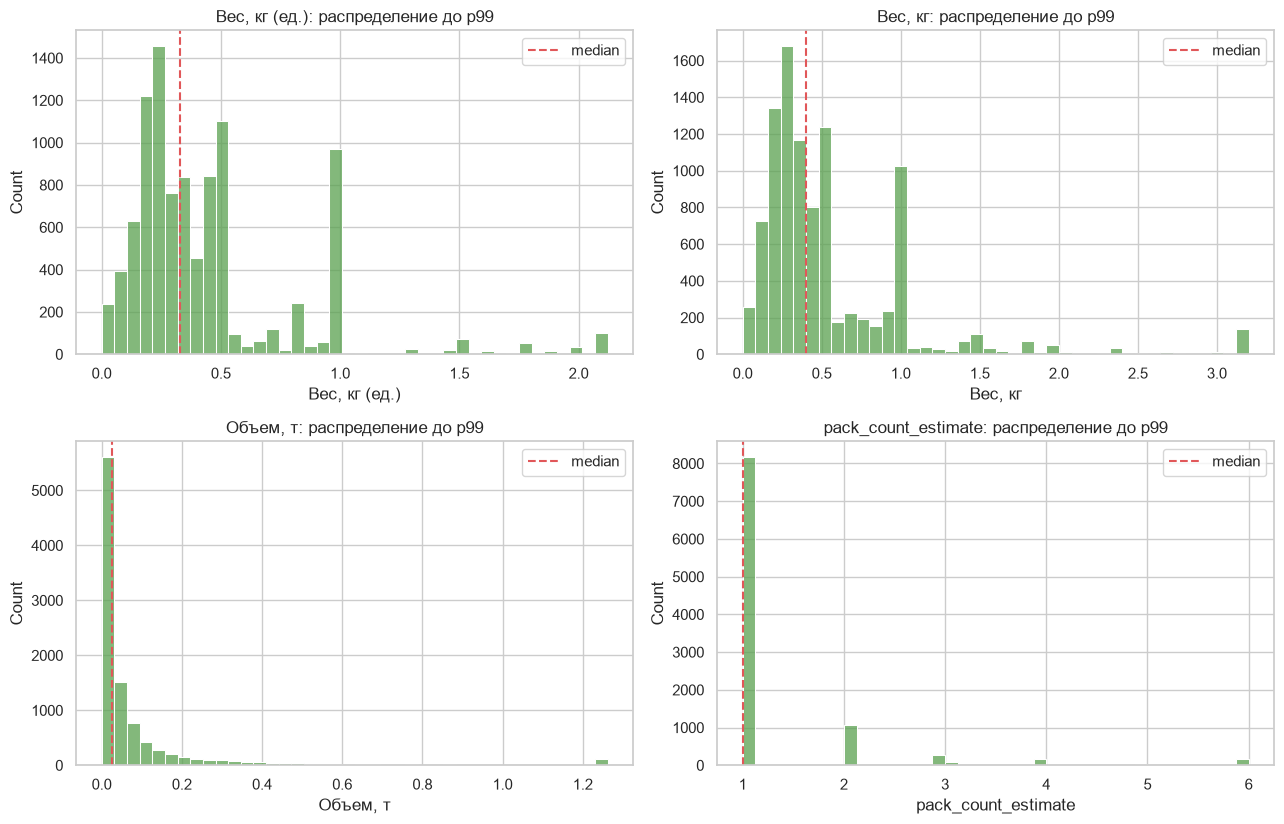

In [12]:

PACK_NUMERIC_CANDIDATES = [
    "Вес, кг (ед.)",
    "Вес, кг",
    "Объем, кг",
    "Объём, кг",
    "Объем, т",
    "Объём, т",
]
pack_numeric_cols = [column for column in PACK_NUMERIC_CANDIDATES if column in analysis_df.columns]

for column in pack_numeric_cols:
    analysis_df[f"{column}__num"] = numeric_series(analysis_df, column)

if {"Вес, кг (ед.)", "Вес, кг"}.issubset(analysis_df.columns):
    unit_weight = analysis_df["Вес, кг (ед.)__num"]
    total_weight = analysis_df["Вес, кг__num"]
    analysis_df["pack_count_estimate"] = np.where(
        (unit_weight > 0) & (total_weight > 0),
        total_weight / unit_weight,
        np.nan,
    )
    pack_numeric_cols = [*pack_numeric_cols, "pack_count_estimate"]

pack_summary_rows = []
for column in pack_numeric_cols:
    series = analysis_df[f"{column}__num"] if f"{column}__num" in analysis_df else analysis_df[column]
    series = pd.to_numeric(series, errors="coerce")
    pack_summary_rows.append(
        {
            "column": column,
            "non_null": int(series.notna().sum()),
            "missing_share": round(float(series.isna().mean()), 4),
            "positive_share": round(float((series > 0).mean()), 4),
            "median": series.median(),
            "p95": series.quantile(0.95),
            "p99": series.quantile(0.99),
            "max": series.max(),
        }
    )

pack_summary = pd.DataFrame(pack_summary_rows)
display(pack_summary)

if pack_numeric_cols:
    n_cols = 2
    n_rows = math.ceil(len(pack_numeric_cols) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 4.2 * n_rows))
    axes = np.array(axes).reshape(-1)

    for ax, column in zip(axes, pack_numeric_cols):
        series = analysis_df[f"{column}__num"] if f"{column}__num" in analysis_df else analysis_df[column]
        values = pd.to_numeric(series, errors="coerce")
        values = values[(values > 0) & values.notna()]
        if values.empty:
            ax.set_title(f"{column}: нет положительных значений")
            ax.axis("off")
            continue
        upper = values.quantile(0.99)
        sns.histplot(values.clip(upper=upper), bins=40, ax=ax, color="#59A14F")
        ax.axvline(values.median(), color="#E15759", linestyle="--", label="median")
        ax.set_title(f"{column}: распределение до p99")
        ax.set_xlabel(column)
        ax.legend()

    for ax in axes[len(pack_numeric_cols):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    display(Markdown("В срезе нет числовых колонок веса и фасовки из ожидаемого списка."))


### Комментарий по результатам

Вес единицы и общий вес заполнены во всех строках. Медианный товар — около 0,33 кг на единицу и 0,40 кг всего; при этом есть наборы из нескольких единиц, поэтому вес и фасовку нужно использовать как отдельный структурный сигнал.

## 10. Аномалии веса и фасовки

Здесь проверяются подозрительные значения в уже готовых колонках веса и фасовки: нули, пропуски, слишком большие значения и странные отношения общего веса к весу единицы.

Такие строки важны не как ошибки ноутбука, а как риск для сравнения товаров. Если вес выглядит неправдоподобно, его нельзя использовать как сильный аргумент при склейке SKU.


,anomaly,rows,share
0,pack_count_estimate_too_large,22,0.00221
1,unit_weight_missing_or_nonpositive,0,0.0
2,unit_weight_too_large,0,0.0
3,total_weight_missing_or_nonpositive,0,0.0
4,total_weight_too_large,0,0.0
5,unit_weight_gt_total_weight,0,0.0
6,pack_count_estimate_fractional,0,0.0


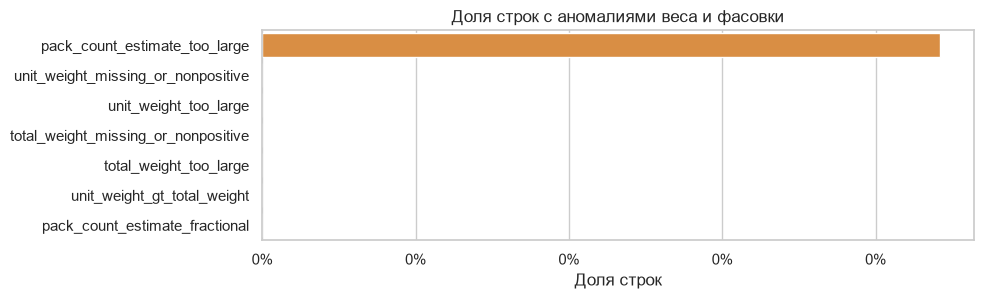

### Примеры строк с подозрительным весом и фасовкой

,Артикул,SKU,Бренд,Подкатегория,"Вес, кг (ед.)","Вес, кг",pack_count_estimate
255,1249070025,"Томатная паста ""Е-ДА!"" 25% ГОСТ порционная 2800 г (70 г х 40 шт.) для приготовления супов, томатного сока, вторых блюд, соусов, пиццы и ...",е-да!,томатная паста,0.070,2.800,40.0
1521,1247646232,"Сок лимона порционный в саше-пакетиках, 50шт по 4мл",None,экзотические,0.004,0.200,50.0
2087,154571436,"Сок лимона порционный в саше-пакетиках, 100шт по 4мл",None,экзотические,0.004,0.400,100.0
2742,280159320,"Набор соусов из 2 видов, порционные 40 шт по 10 г",махеевъ,наборы,0.010,0.400,40.0
2863,266536949,"Майонез Провансаль порционный 67%, 40 шт по 10 гр",махеевъ,майонезные,0.010,0.400,40.0
3546,443051171,"Соус микс соусов (25мл х 25шт), 625г",heinz,None,0.025,0.625,25.0
3730,269386862,"Кетчуп Томатный порционный, 60 шт по 10 гр",махеевъ,кетчуп,0.010,0.600,60.0
3870,255944188,Васаби порционный в стиках 3кг (600 шт х 5 г),shefu-san,васаби,0.005,3.000,600.0
4080,272137916,"Набор соусов из 3 видов, порционные 60 шт по 10 г",махеевъ,наборы,0.010,0.600,60.0
4101,269386860,"Майонез Провансаль порционный 67%, 120 шт по 10 гр",махеевъ,майонезные,0.010,1.200,120.0


In [13]:

anomaly_flags = pd.DataFrame(index=analysis_df.index)

if "Вес, кг (ед.)__num" in analysis_df:
    anomaly_flags["unit_weight_missing_or_nonpositive"] = analysis_df["Вес, кг (ед.)__num"].isna() | (analysis_df["Вес, кг (ед.)__num"] <= 0)
    anomaly_flags["unit_weight_too_large"] = analysis_df["Вес, кг (ед.)__num"] > MAX_REASONABLE_WEIGHT_KG

if "Вес, кг__num" in analysis_df:
    anomaly_flags["total_weight_missing_or_nonpositive"] = analysis_df["Вес, кг__num"].isna() | (analysis_df["Вес, кг__num"] <= 0)
    anomaly_flags["total_weight_too_large"] = analysis_df["Вес, кг__num"] > MAX_REASONABLE_WEIGHT_KG

if {"Вес, кг (ед.)__num", "Вес, кг__num"}.issubset(analysis_df.columns):
    anomaly_flags["unit_weight_gt_total_weight"] = analysis_df["Вес, кг (ед.)__num"] > analysis_df["Вес, кг__num"] + 1e-9

if "pack_count_estimate" in analysis_df:
    anomaly_flags["pack_count_estimate_too_large"] = analysis_df["pack_count_estimate"] > 24
    anomaly_flags["pack_count_estimate_fractional"] = (
        analysis_df["pack_count_estimate"].notna()
        & (analysis_df["pack_count_estimate"] > 1.05)
        & ((analysis_df["pack_count_estimate"] - analysis_df["pack_count_estimate"].round()).abs() > 0.05)
    )

if "Вес аномалия" in analysis_df.columns:
    anomaly_flags["parser_weight_anomaly_flag"] = analysis_df["Вес аномалия"].astype("string").str.casefold().isin(["true", "1", "yes", "да"])

if anomaly_flags.empty:
    display(Markdown("Не нашлось доступных колонок веса и фасовки для проверки аномалий."))
else:
    anomaly_summary = anomaly_flags.sum().sort_values(ascending=False).rename_axis("anomaly").reset_index(name="rows")
    anomaly_summary["share"] = anomaly_summary["rows"] / len(analysis_df)
    display(anomaly_summary)

    plt.figure(figsize=(10, max(3, 0.45 * len(anomaly_summary))))
    sns.barplot(data=anomaly_summary, y="anomaly", x="share", color="#F28E2B")
    plt.gca().xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
    plt.title("Доля строк с аномалиями веса и фасовки")
    plt.xlabel("Доля строк")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

    any_anomaly = anomaly_flags.any(axis=1)
    anomaly_columns_for_view = [
        column
        for column in [SKU_ID_COL, TITLE_COL, BRAND_COL, "Подкатегория", "Вес, кг (ед.)", "Вес, кг", "pack_count_estimate"]
        if column in analysis_df.columns
    ]
    display(Markdown("### Примеры строк с подозрительным весом и фасовкой"))
    display(analysis_df.loc[any_anomaly, anomaly_columns_for_view].head(25))


### Комментарий по результатам

Основная найденная проблема — 22 строки с подозрительно большим количеством единиц в наборе. Остальные проверки веса почти чистые, значит весовые признаки можно использовать, но такие выбросы надо отлавливать до финальной склейки.

## 11. Информативность названий товаров

Для поиска пар товаров для сравнения важно понимать, насколько полезно само название товара. Слишком короткие названия дают мало сигнала, а слишком длинные часто содержат маркетинговые добавки и шум.

Графики показывают длину названия товара в символах и словах. Это помогает увидеть типичный диапазон и найти крайние случаи для ручного просмотра.


,count,mean,std,min,5%,25%,50%,75%,95%,99%,max
title_char_len,9953.0,48.433337,22.395322,13.0,23.0,34.0,44.0,57.0,91.0,129.0,198.0
title_token_len,9953.0,8.208882,3.395706,3.0,4.0,6.0,8.0,10.0,15.0,21.0,31.0


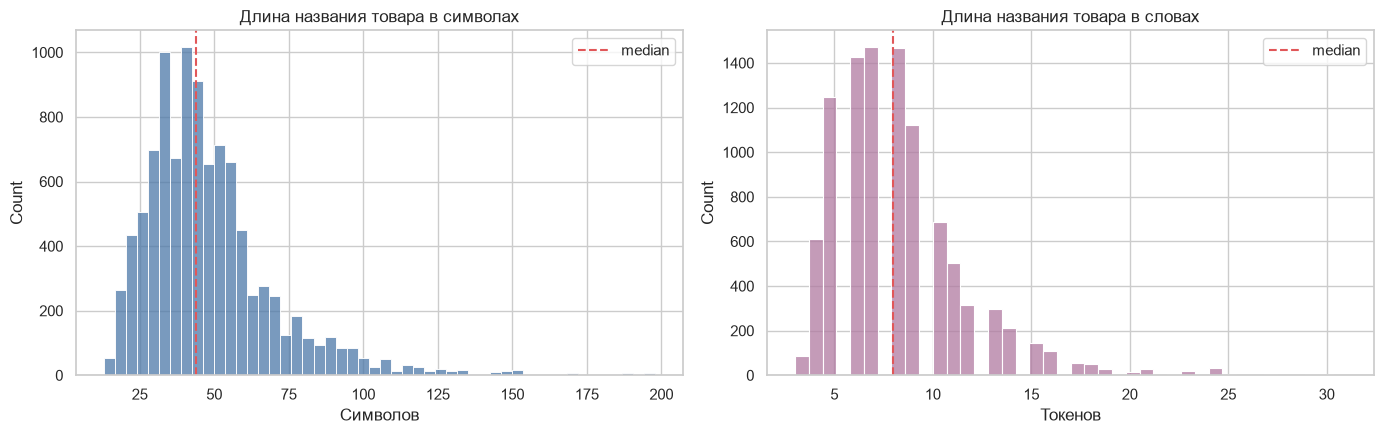

### Самые короткие названия товара

,Артикул,SKU,Бренд,"Вес, кг"
44,3417634431,Наршараб 760 г,sultan group,0.760
732,3417666724,Гранатовый соус 800г,narsarab,0.800
2033,1557386514,Соус соевый 250мл,takemura,0.250
2331,3668683138,Уксус 1280мл. 1шт,None,1.280
2427,75586478,Соус лемонграсс 470мл,tamaki,0.470
2674,75586481,Соус Шрирача 470мл,tamaki,0.470
2768,495611676,Соус Соевый 470мл,tamaki,0.470
2776,309683437,Соус Ворчестер 290мл,lea&perrins,0.290
2783,11146982,Рыбный соус 840г,aroy-d,0.840
2960,77014192,"Соус Вустерский, 250мл.",sanbonsai,0.250


### Самые длинные названия товара

,Артикул,SKU,Бренд,"Вес, кг"
845,3164327833,"Низкокалорийный соус из мидий от ВНИРО с лаймом и лимоном. Освежающая замена соевому соусу для морепродуктов, рыбы и салатов. Без сахара...",вниро,0.25
5304,3164327833,"Низкокалорийный соус из мидий от ВНИРО с лаймом и лимоном. Освежающая замена соевому соусу для морепродуктов, рыбы и салатов. Без сахара...",вниро,0.25
809,447354633,"Соус ананасовый с перцем чили Tamaki 470мл, слегка острый с вкраплениями перца чили и чабреца, для креветок, блюд с рисом, к овощам и мо...",tamaki,0.47
1881,3164326888,"Секрет учёных ВНИРО: низкокалорийный соус из мидий, который заменит соевый соус. Пикантный с луком (не режет, а раскрывает вкус. Основа ...",вниро,0.25
5741,447354633,"Соус ананасовый с перцем чили Tamaki 470мл, слегка острый с вкраплениями перца чили и чабреца, для креветок, блюд с рисом, к овощам и мо...",tamaki,0.47
6767,3164326888,"Секрет учёных ВНИРО: низкокалорийный соус из мидий, который заменит соевый соус. Пикантный с луком (не режет, а раскрывает вкус. Основа ...",вниро,0.25
407,1492599903,"Соусы набор ассорти 5 шт по 100г: брусничный с грушей, малиновый с чили, клюквенный с апельсином, имбирем и корицей, облепиховый с ананс...","тм ""сибирская ягода""",0.50
2348,1396104015,"Сырный соус Tamaki 1 кг для картофеля фри, бургеров, наггетсов, хот-догов и начос. Профессиональный густой соус со вкусом чеддера. Выгод...",tamaki,1.00
5062,1396104015,"Сырный соус Tamaki 1 кг для картофеля фри, бургеров, наггетсов, хот-догов и начос. Профессиональный густой соус со вкусом чеддера. Выгод...",tamaki,1.00
5099,2309205392,"Соус Tamaki Японский кетчуп (Тонкацу), 470 мл, для мяса стейков ребрышек и барбекю густой паназиатский фруктово-овощной маринад для грил...",tamaki,0.47


In [14]:

title_length_summary = analysis_df[["title_char_len", "title_token_len"]].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
display(title_length_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(analysis_df["title_char_len"], bins=50, ax=axes[0], color="#4C78A8")
axes[0].axvline(analysis_df["title_char_len"].median(), color="#E15759", linestyle="--", label="median")
axes[0].set_title("Длина названия товара в символах")
axes[0].set_xlabel("Символов")
axes[0].legend()

sns.histplot(analysis_df["title_token_len"], bins=40, ax=axes[1], color="#B07AA1")
axes[1].axvline(analysis_df["title_token_len"].median(), color="#E15759", linestyle="--", label="median")
axes[1].set_title("Длина названия товара в словах")
axes[1].set_xlabel("Токенов")
axes[1].legend()
plt.tight_layout()
plt.show()

short_titles = analysis_df.nsmallest(15, "title_token_len")[[column for column in [SKU_ID_COL, TITLE_COL, BRAND_COL, "Вес, кг"] if column in analysis_df.columns]]
long_titles = analysis_df.nlargest(15, "title_token_len")[[column for column in [SKU_ID_COL, TITLE_COL, BRAND_COL, "Вес, кг"] if column in analysis_df.columns]]

display(Markdown("### Самые короткие названия товара"))
display(short_titles)
display(Markdown("### Самые длинные названия товара"))
display(long_titles)


### Комментарий по результатам

Названия товара обычно достаточно информативны: медиана — 44 символа и 8 слов. Короткие названия требуют осторожности, а слишком длинные часто содержат маркетинговые добавки, которые могут мешать сравнению.

## 12. Частотный анализ слов в названиях

Это простой подсчёт слов и устойчивых сочетаний, а не модель. Он показывает, какие вкусы, типы продукта, упаковки и служебные слова часто встречаются в выбранной категории.

Такая проверка помогает заранее увидеть лексику, по которой товары могут быть похожи или, наоборот, отличаться. Эти наблюдения пригодятся при подготовке пар для ручной разметки и последующего сравнения моделей.


,token,rows_or_mentions
0,соевый,982
1,паста,830
2,чили,792
3,острый,742
4,натуральный,624
5,уксус,549
6,сладкий,533
7,томатный,477
8,низкокалорийный,413
9,мяса,401


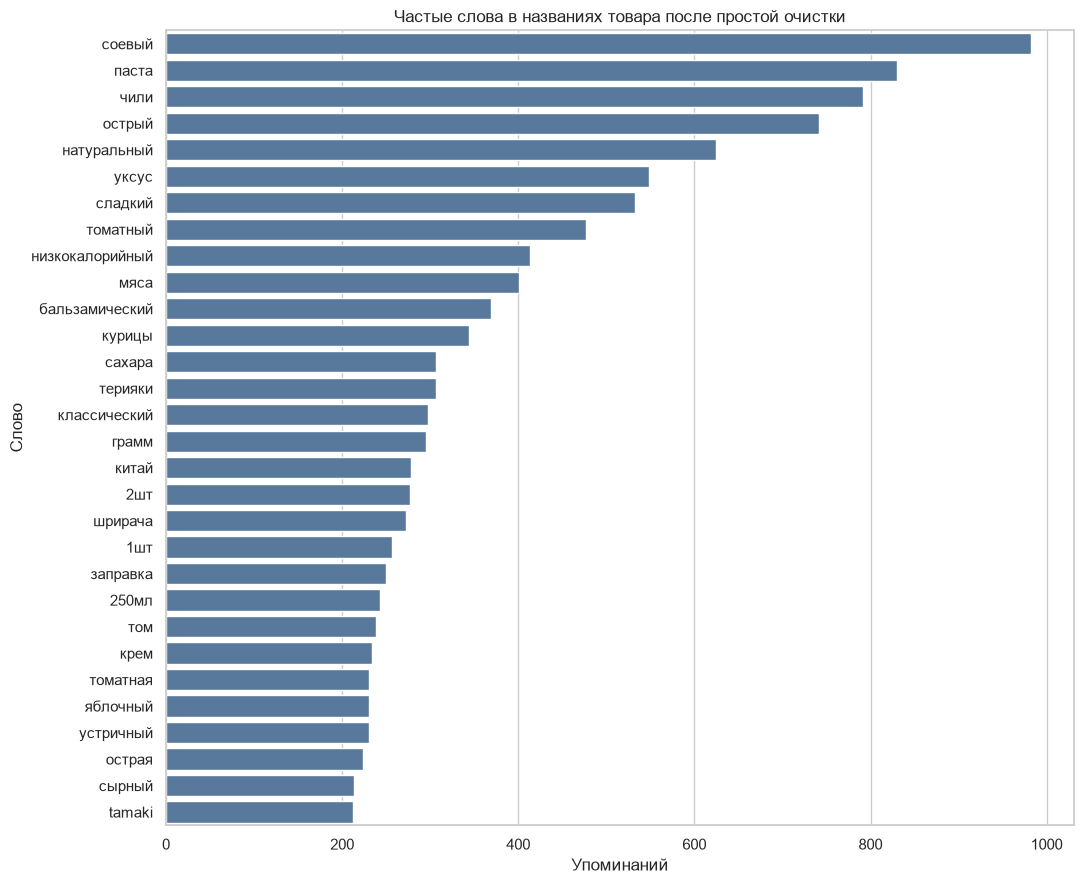

In [15]:

STOPWORDS = {
    "и", "в", "во", "на", "с", "со", "для", "без", "из", "по", "к", "от", "до", "под", "над",
    "а", "или", "не", "за", "при", "the", "and", "with", "of", "шт", "г", "гр", "кг", "мл", "л",
    "x", "х", "уп", "упак", "пак", "набор", "соус", "соуса", "соусы",
}


def useful_tokens(tokens: list[str]) -> list[str]:
    '''Убирает короткие и очень служебные токены для частотного обзора.'''
    out = []
    for token in tokens:
        if token in STOPWORDS:
            continue
        if token.isdigit():
            continue
        if len(token) < 3:
            continue
        out.append(token)
    return out


analysis_df["useful_title_tokens"] = analysis_df["title_tokens"].map(useful_tokens)
all_tokens = [token for tokens in analysis_df["useful_title_tokens"] for token in tokens]
token_counts = pd.DataFrame(Counter(all_tokens).most_common(40), columns=["token", "rows_or_mentions"])
display(token_counts)

plt.figure(figsize=(11, 9))
sns.barplot(data=token_counts.head(30), y="token", x="rows_or_mentions", color="#4C78A8")
plt.title("Частые слова в названиях товара после простой очистки")
plt.xlabel("Упоминаний")
plt.ylabel("Слово")
plt.tight_layout()
plt.show()


### Частые биграммы

,bigram,mentions
0,сладкий чили,261
1,томатная паста,220
2,sen soy,148
3,кисло сладкий,135
4,уксус натуральный,134
5,яблочный уксус,133
6,паста том,129
7,низкокалорийный сахара,127
8,натуральный нефильтрованный,115
9,чили курицы,114


### Частые триграммы

,trigram,mentions
0,сладкий чили курицы,112
1,яблочный уксус натуральный,104
2,уксус натуральный нефильтрованный,79
3,основа коктейлей напитков,60
4,приправа рыбы мяса,60
5,коктейлей напитков заправка,58
6,напитков заправка салата,58
7,заправка салата приправа,58
8,салата приправа рыбы,58
9,хрустящим перцем чили,49


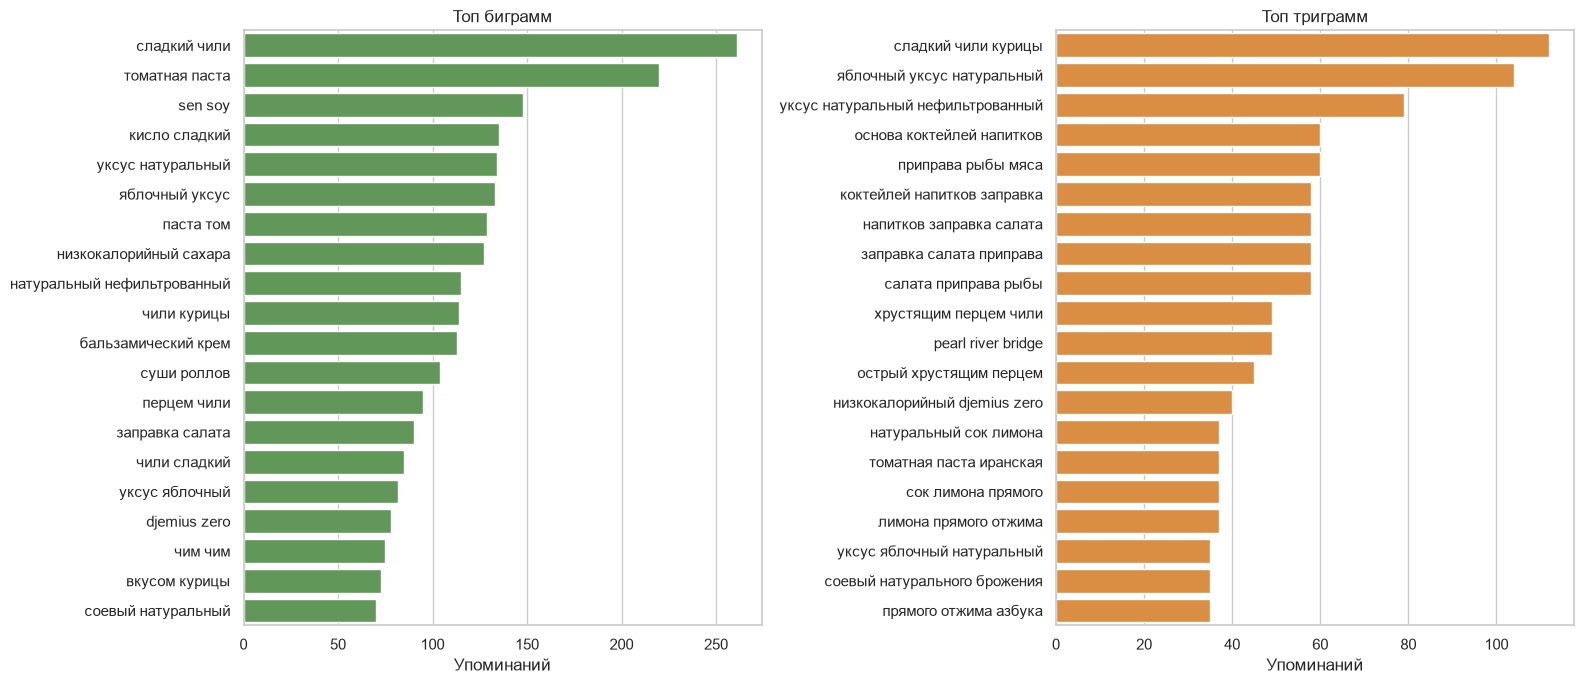

In [16]:

def ngrams(tokens: list[str], n: int) -> list[str]:
    '''Строит n-граммы из уже очищенных токенов.'''
    if len(tokens) < n:
        return []
    return [" ".join(tokens[i : i + n]) for i in range(len(tokens) - n + 1)]


bigram_counts = Counter()
trigram_counts = Counter()
for tokens in analysis_df["useful_title_tokens"]:
    bigram_counts.update(ngrams(tokens, 2))
    trigram_counts.update(ngrams(tokens, 3))

bigrams_df = pd.DataFrame(bigram_counts.most_common(25), columns=["bigram", "mentions"])
trigrams_df = pd.DataFrame(trigram_counts.most_common(25), columns=["trigram", "mentions"])

display(Markdown("### Частые биграммы"))
display(bigrams_df)
display(Markdown("### Частые триграммы"))
display(trigrams_df)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.barplot(data=bigrams_df.head(20), y="bigram", x="mentions", ax=axes[0], color="#59A14F")
axes[0].set_title("Топ биграмм")
axes[0].set_xlabel("Упоминаний")
axes[0].set_ylabel("")
sns.barplot(data=trigrams_df.head(20), y="trigram", x="mentions", ax=axes[1], color="#F28E2B")
axes[1].set_title("Топ триграмм")
axes[1].set_xlabel("Упоминаний")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()


,hint,rows,share
13,соевый,976,0.098061
26,паста,813,0.081684
6,острый,789,0.079273
9,чили,787,0.079072
7,сладкий,528,0.053049
10,томатный,475,0.047724
19,бальзамический,369,0.037074
5,терияки,306,0.030744
20,устричный,231,0.023209
2,сырный,209,0.020999


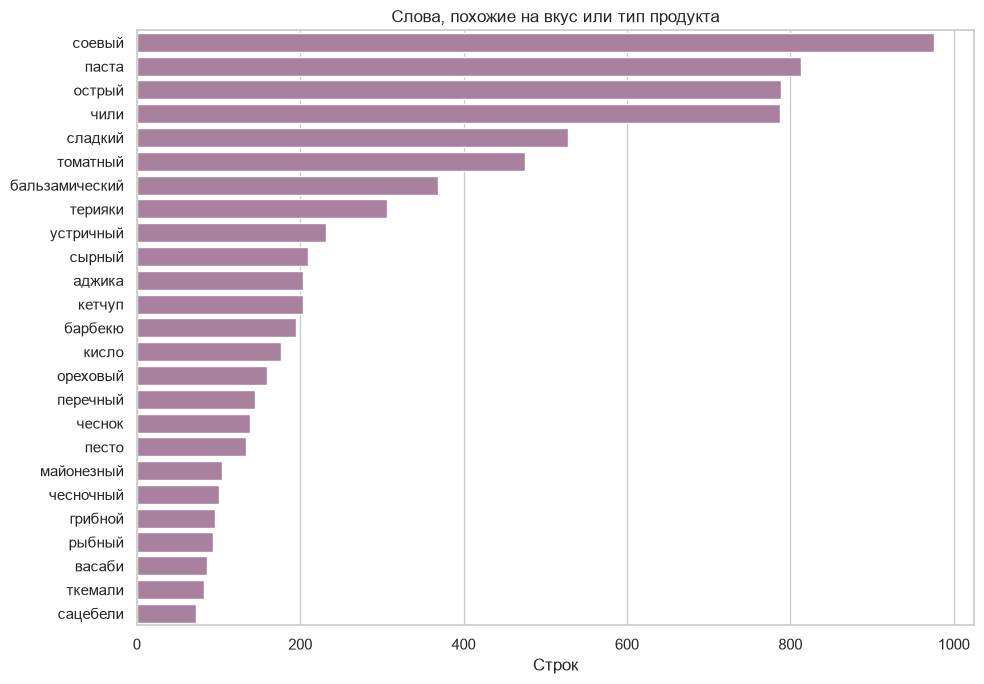

In [17]:

DOMAIN_HINTS = [
    "чесночный", "чеснок", "сырный", "барбекю", "bbq", "терияки", "острый", "сладкий", "кисло", "чили",
    "томатный", "песто", "васаби", "соевый", "майонезный", "грибной", "сливочный", "ореховый", "перечный",
    "бальзамический", "устричный", "рыбный", "ткемали", "сацебели", "аджика", "кетчуп", "паста",
]

hint_rows = []
for hint in DOMAIN_HINTS:
    mask = analysis_df["title_norm"].str.contains(re.escape(hint), na=False)
    hint_rows.append({"hint": hint, "rows": int(mask.sum()), "share": float(mask.mean())})

hints_df = pd.DataFrame(hint_rows).sort_values("rows", ascending=False)
display(hints_df)

plt.figure(figsize=(10, 7))
sns.barplot(data=hints_df[hints_df["rows"] > 0].head(25), y="hint", x="rows", color="#B07AA1")
plt.title("Слова, похожие на вкус или тип продукта")
plt.xlabel("Строк")
plt.ylabel("")
plt.tight_layout()
plt.show()


### Комментарий по результатам

Частые слова хорошо отражают реальные подтипы: соевый, паста, чили, острый, уксус, томатный. Эти слова полезны для поиска пар товаров для сравнения и для отбора похожих, но разных товаров в ручную разметку.

## 13. Бренд, фасовка и числовые связи

Матрица «бренд × округлённый общий вес» показывает, где много товаров одного бренда в одинаковой или близкой фасовке. Это удобный способ найти плотные зоны, в которых вероятны как дубли, так и очень похожие разные товары.

Корреляционная тепловая карта нужна только как проверка числовых полей. Она не доказывает наличие дублей, но помогает заметить странные связи, выбросы и признаки, которые требуют осторожности.


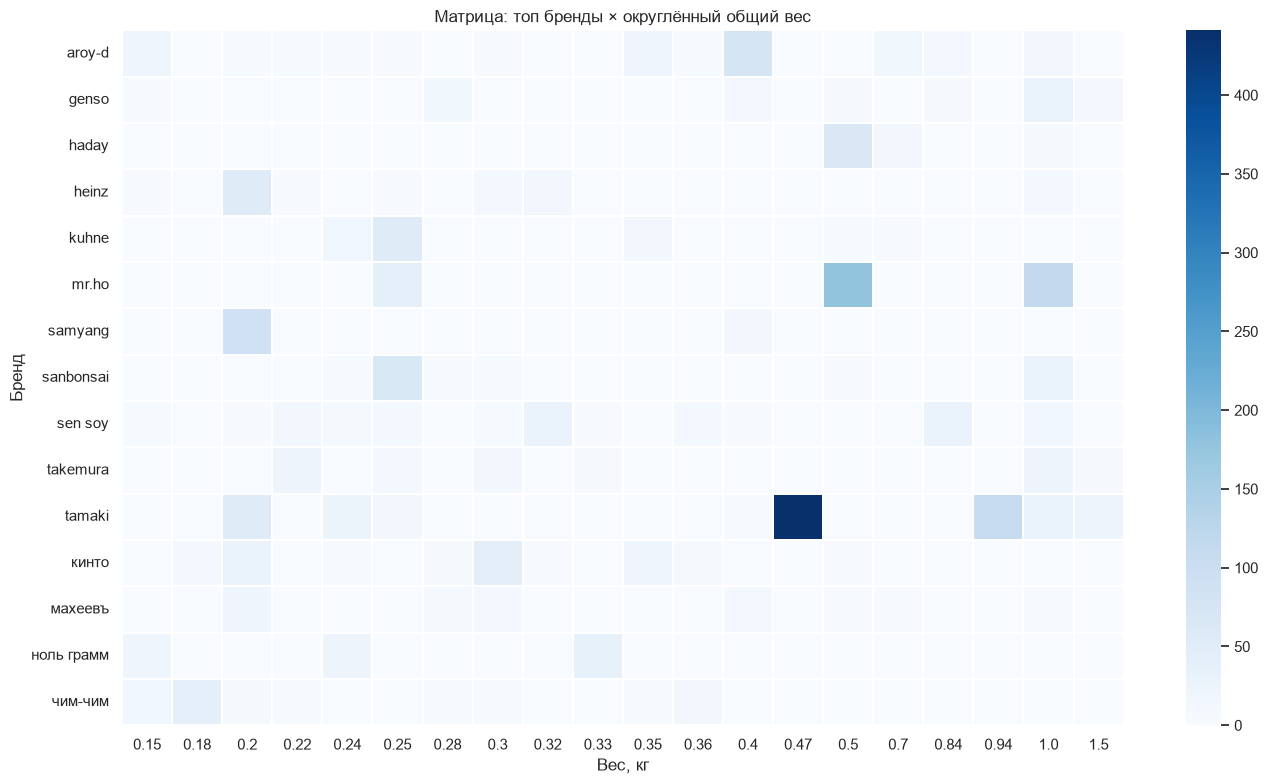

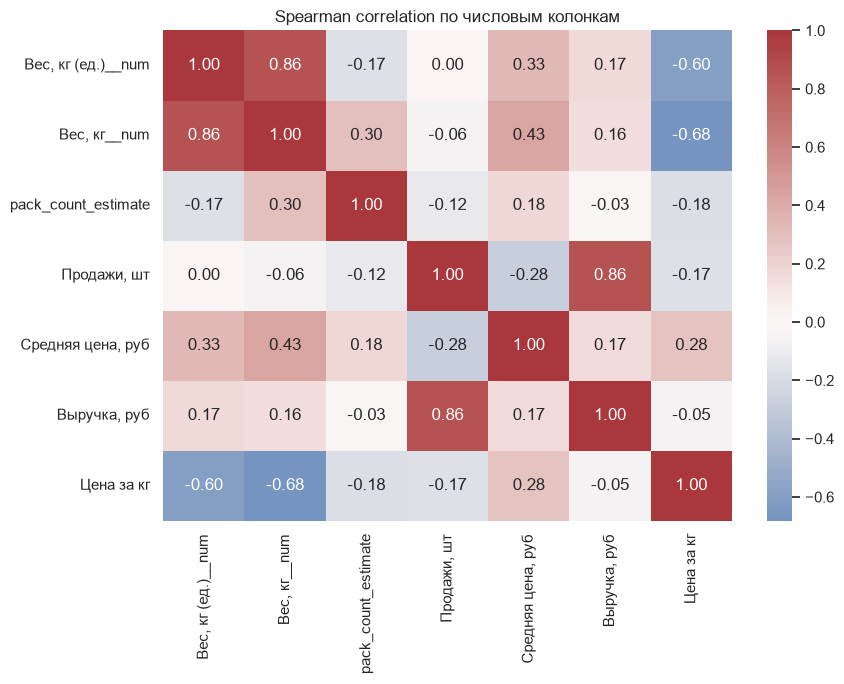

In [18]:

if BRAND_COL and "Вес, кг__num" in analysis_df.columns:
    top_brand_names = analysis_df.loc[analysis_df["brand_norm"].ne(""), "brand_norm"].value_counts().head(15).index
    brand_pack_df = analysis_df.loc[analysis_df["brand_norm"].isin(top_brand_names)].copy()
    brand_pack_df["total_weight_rounded"] = brand_pack_df["Вес, кг__num"].round(2)
    top_weights = brand_pack_df["total_weight_rounded"].value_counts().head(20).index
    matrix = pd.crosstab(
        brand_pack_df.loc[brand_pack_df["total_weight_rounded"].isin(top_weights), "brand_norm"],
        brand_pack_df.loc[brand_pack_df["total_weight_rounded"].isin(top_weights), "total_weight_rounded"],
    )
    plt.figure(figsize=(14, 8))
    sns.heatmap(matrix, cmap="Blues", linewidths=0.2)
    plt.title("Матрица: топ бренды × округлённый общий вес")
    plt.xlabel("Вес, кг")
    plt.ylabel("Бренд")
    plt.tight_layout()
    plt.show()
else:
    display(Markdown("Матрица brand × pack пропущена: нет brand или общего веса."))

numeric_for_corr = []
for column in ["Вес, кг (ед.)__num", "Вес, кг__num", "pack_count_estimate", "Продажи, шт", "Средняя цена, руб", "Выручка, руб", "Цена за кг"]:
    if column in analysis_df.columns:
        numeric_for_corr.append(column)
    elif column in df.columns:
        analysis_df[f"{column}__num"] = numeric_series(analysis_df, column)
        numeric_for_corr.append(f"{column}__num")

corr_frame = analysis_df[numeric_for_corr].apply(pd.to_numeric, errors="coerce") if numeric_for_corr else pd.DataFrame()
if corr_frame.shape[1] >= 2:
    corr = corr_frame.corr(method="spearman")
    plt.figure(figsize=(9, 7))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
    plt.title("Spearman correlation по числовым колонкам")
    plt.tight_layout()
    plt.show()
else:
    display(Markdown("Недостаточно числовых колонок для корреляционной матрицы."))


### Комментарий по результатам

Матрица брендов и веса показывает плотные зоны, где особенно много потенциальных дублей и похожих товаров. Корреляции числовых полей не принимают решение о склейке, но помогают проверить, нет ли странных связей в данных.

## 14. Примеры товаров, похожих на дубли, без модели

Этот блок не принимает решение о склейке. Он выбирает небольшой набор строк, где совпадает очищенное название товара и, если доступны данные, совпадают бренд и округлённый вес.

Такие примеры нужны для ручной проверки и объяснения следующего шага: какие пары похожи на настоящие дубли и почему их стоит отправлять в модель сравнения пар.


In [19]:

def compact_title_for_exact_review(value: object) -> str:
    '''Нормализует название товара для поиска точных повторов в примерах.'''
    text = str(value or "").casefold().replace("ё", "е")
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"[^0-9a-zа-я]+", " ", text)
    return text.strip()


review_df = analysis_df.copy()
review_df["title_exact_review_key"] = review_df[TITLE_COL].map(compact_title_for_exact_review)
if "Вес, кг__num" in review_df.columns:
    review_df["total_weight_review_key"] = review_df["Вес, кг__num"].round(3)
else:
    review_df["total_weight_review_key"] = np.nan

near_duplicate_group_cols = ["title_exact_review_key"]
if BRAND_COL:
    near_duplicate_group_cols.append("brand_norm")
if "total_weight_review_key" in review_df.columns:
    near_duplicate_group_cols.append("total_weight_review_key")

pairs = []
view_columns = [column for column in [SKU_ID_COL, TITLE_COL, BRAND_COL, "Подкатегория", "Вес, кг (ед.)", "Вес, кг", "Маркетплейс", "__project_name"] if column in review_df.columns]
for _, group in review_df[review_df["title_exact_review_key"].ne("")].groupby(near_duplicate_group_cols, dropna=False):
    if len(group) < 2:
        continue
    sample = group.sort_values(view_columns[0] if view_columns else TITLE_COL).head(3)
    for left_idx, right_idx in combinations(sample.index[:3], 2):
        left = review_df.loc[left_idx]
        right = review_df.loc[right_idx]
        pairs.append(
            {
                "пояснение": "совпали очищенное название товара, бренд и вес",
                "артикул_a": left.get(SKU_ID_COL),
                "название_a": left.get(TITLE_COL),
                "бренд_a": left.get(BRAND_COL) if BRAND_COL else None,
                "вес_a": left.get("Вес, кг"),
                "артикул_b": right.get(SKU_ID_COL),
                "название_b": right.get(TITLE_COL),
                "бренд_b": right.get(BRAND_COL) if BRAND_COL else None,
                "вес_b": right.get("Вес, кг"),
            }
        )
        if len(pairs) >= MAX_EXAMPLE_PAIRS:
            break
    if len(pairs) >= MAX_EXAMPLE_PAIRS:
        break

near_duplicates_df = pd.DataFrame(pairs)
if near_duplicates_df.empty:
    display(Markdown("Точных повторов по простому ключу не найдено. Это нормально: на следующем этапе понадобится отдельный поиск пар товаров для сравнения."))
else:
    display(near_duplicates_df)


,пояснение,артикул_a,название_a,бренд_a,вес_a,артикул_b,название_b,бренд_b,вес_b
0,"совпали очищенное название товара, бренд и вес",2635146429,"1 л, Винный уксус белый натуральный фильтрованный, 6 %, БИОВИТА, ПЭТ",биовита,1.00,2635146429,"1 л, Винный уксус белый натуральный фильтрованный, 6 %, БИОВИТА, ПЭТ",биовита,1.00
1,"совпали очищенное название товара, бренд и вес",1117738301,"1 литр, Винный уксус натуральный нефильтрованный, 6 %, БИОВИТА, ПЭТ",биовита,1.00,1117738301,"1 литр, Винный уксус натуральный нефильтрованный, 6 %, БИОВИТА, ПЭТ",биовита,1.00
2,"совпали очищенное название товара, бренд и вес",1615508835,"1 литр, Рисовый уксус натуральный СОУС, 4 %, БИОВИТА, ПЭТ",биовита,1.00,1615508835,"1 литр, Рисовый уксус натуральный СОУС, 4 %, БИОВИТА, ПЭТ",биовита,1.00
3,"совпали очищенное название товара, бренд и вес",882199487,"1 Литр Яблочный уксус Натуральный, Brivio",la vida organica,1.00,882199487,"1 Литр Яблочный уксус Натуральный, Brivio",la vida organica,1.00
4,"совпали очищенное название товара, бренд и вес",1469719012,"1 литр, Яблочный уксус натуральный нефильтрованный, 6 %, БИОВИТА, ПЭТ",биовита,1.00,1469719012,"1 литр, Яблочный уксус натуральный нефильтрованный, 6 %, БИОВИТА, ПЭТ",биовита,1.00
5,"совпали очищенное название товара, бренд и вес",1790411346,"1 литр, Яблочный уксус натуральный нефильтрованный, 6 %, БИОВИТА, стекло",биовита,1.00,1790411346,"1 литр, Яблочный уксус натуральный нефильтрованный, 6 %, БИОВИТА, стекло",биовита,1.00
6,"совпали очищенное название товара, бренд и вес",1613544549,"1 Литр Яблочный Уксус натуральный нефильтрованный непастеризованный,Sabroza, Италия, c маткой Стекло",sabroza,1.00,1613544549,"1 Литр Яблочный Уксус натуральный нефильтрованный непастеризованный,Sabroza, Италия, c маткой Стекло",sabroza,1.00
7,"совпали очищенное название товара, бренд и вес",1117814960,"1 литр, Яблочный уксус натуральный фильтрованный, 6 %, БИОВИТА, ПЭТ",биовита,1.00,1117814960,"1 литр, Яблочный уксус натуральный фильтрованный, 6 %, БИОВИТА, ПЭТ",биовита,1.00
8,"совпали очищенное название товара, бренд и вес",1790440283,"1 литр, Яблочный уксус натуральный фильтрованный, 6 %, БИОВИТА, стекло",биовита,1.00,1790440283,"1 литр, Яблочный уксус натуральный фильтрованный, 6 %, БИОВИТА, стекло",биовита,1.00
9,"совпали очищенное название товара, бренд и вес",1117742918,"1000 мл, Облепиховый уксус натуральный нефильтрованный, 6 %, БИОВИТА, ПЭТ",биовита,1.00,1117742918,"1000 мл, Облепиховый уксус натуральный нефильтрованный, 6 %, БИОВИТА, ПЭТ",биовита,1.00


### Комментарий по результатам

Найдено 15 ручных примеров товаров, похожих на дубли по простому ключу. Это не финальное решение, а стартовый набор случаев, по которым удобно объяснять, зачем дальше нужна модель сравнения пар.

## 15. Примеры похожих, но разных товаров без модели

Здесь ищем пары, которые легко перепутать: один бренд и близкая фасовка, но разные вкусы, типы продукта или подкатегории. Такие пары особенно важны, потому что простые правила часто склеивают их ошибочно.

Эти примеры нужны для будущей разметки как «похожие, но разные товары». Они помогают обучать и проверять модель не только на очевидных случаях, но и на сложных границах между SKU.


In [20]:

HARD_NEGATIVE_HINTS = {
    "чесночный", "чеснок", "сырный", "барбекю", "bbq", "терияки", "острый", "сладкий", "чили", "томатный",
    "песто", "васаби", "соевый", "грибной", "сливочный", "ореховый", "перечный", "кетчуп", "паста", "аджика",
}


def hint_set(tokens: list[str]) -> set[str]:
    '''Выделяет заранее заданные слова вкуса или типа продукта для ручного просмотра.'''
    return set(tokens) & HARD_NEGATIVE_HINTS


review_df["hint_set"] = review_df["useful_title_tokens"].map(hint_set) if "useful_title_tokens" in review_df else analysis_df["useful_title_tokens"].map(hint_set)
review_df["weight_bucket"] = review_df["Вес, кг__num"].round(2) if "Вес, кг__num" in review_df else np.nan

hard_negative_pairs = []
if BRAND_COL and "weight_bucket" in review_df.columns:
    grouped = review_df[
        review_df["brand_norm"].ne("")
        & review_df["weight_bucket"].notna()
        & review_df["title_exact_review_key"].ne("")
    ].groupby(["brand_norm", "weight_bucket"], dropna=False)

    for _, group in grouped:
        if len(group) < 2 or len(group) > 80:
            continue
        rows = group.head(30)
        for left_idx, right_idx in combinations(rows.index, 2):
            left = review_df.loc[left_idx]
            right = review_df.loc[right_idx]
            if left[TITLE_COL] == right[TITLE_COL]:
                continue
            different_subcategory = "Подкатегория" in review_df.columns and str(left.get("Подкатегория")) != str(right.get("Подкатегория"))
            different_hints = bool(left["hint_set"] or right["hint_set"]) and left["hint_set"] != right["hint_set"]
            if not (different_subcategory or different_hints):
                continue
            hard_negative_pairs.append(
                {
                    "пояснение": "совпали бренд и вес, но различаются тип или вкус",
                    "артикул_a": left.get(SKU_ID_COL),
                    "название_a": left.get(TITLE_COL),
                    "подкатегория_a": left.get("Подкатегория"),
                    "слова_типа_a": ", ".join(sorted(left["hint_set"])),
                    "артикул_b": right.get(SKU_ID_COL),
                    "название_b": right.get(TITLE_COL),
                    "подкатегория_b": right.get("Подкатегория"),
                    "слова_типа_b": ", ".join(sorted(right["hint_set"])),
                    "бренд": left.get(BRAND_COL) if BRAND_COL else None,
                    "вес": left.get("Вес, кг"),
                }
            )
            if len(hard_negative_pairs) >= MAX_HARD_NEGATIVE_EXAMPLES:
                break
        if len(hard_negative_pairs) >= MAX_HARD_NEGATIVE_EXAMPLES:
            break

hard_negatives_df = pd.DataFrame(hard_negative_pairs)
if hard_negatives_df.empty:
    display(Markdown("Примеры похожих, но разных товаров по простым правилам не найдены. Можно расширить ручной срез после разметки."))
else:
    display(hard_negatives_df)


,пояснение,артикул_a,название_a,подкатегория_a,слова_типа_a,артикул_b,название_b,подкатегория_b,слова_типа_b,бренд,вес
0,"совпали бренд и вес, но различаются тип или вкус",3138957471,Хрен столовый Боярский 4 шт.*160 г Белорусский ABC,хрен,,3138893251,ABC Горчица Французская 320г. 2шт.,горчица,,abc,0.64
1,"совпали бренд и вес, но различаются тип или вкус",3138893251,ABC Горчица Французская 320г. 2шт.,горчица,,2980018933,Хрен со свеклой 4 шт.*160г Белорусский ABC,хрен,,abc,0.64
2,"совпали бренд и вес, но различаются тип или вкус",3138893251,ABC Горчица Французская 320г. 2шт.,горчица,,2980018933,Хрен со свеклой 4 шт.*160г Белорусский ABC,хрен,,abc,0.64
3,"совпали бренд и вес, но различаются тип или вкус",1991192655,Akiso Уксус Рисовый 4% 250мл. 1шт,уксус,,1999445706,"Соус Кунжутный Akiso 0,25л.",экзотические,,akiso,0.25
4,"совпали бренд и вес, но различаются тип или вкус",1991192655,Akiso Уксус Рисовый 4% 250мл. 1шт,уксус,,1970696291,"Соус Унаги Akiso 0,25л. ПРЕМИУМ",экзотические,,akiso,0.25
5,"совпали бренд и вес, но различаются тип или вкус",1991192655,Akiso Уксус Рисовый 4% 250мл. 1шт,уксус,,1999445504,"Соус Ореховый Akiso 0,25л.",экзотические,ореховый,akiso,0.25
6,"совпали бренд и вес, но различаются тип или вкус",1991192655,Akiso Уксус Рисовый 4% 250мл. 1шт,уксус,,471289605,"Соус Кунжутный 0,25л.",экзотические,,akiso,0.25
7,"совпали бренд и вес, но различаются тип или вкус",1991192655,Akiso Уксус Рисовый 4% 250мл. 1шт,уксус,,471297691,"Соус Ореховый 0,25л.",экзотические,ореховый,akiso,0.25
8,"совпали бренд и вес, но различаются тип или вкус",1991192655,Akiso Уксус Рисовый 4% 250мл. 1шт,уксус,,473465316,"Соус Унаги густой 0,25л. для суши, роллов и угря",экзотические,,akiso,0.25
9,"совпали бренд и вес, но различаются тип или вкус",1991192655,Akiso Уксус Рисовый 4% 250мл. 1шт,уксус,,1999445504,"Соус Ореховый Akiso 0,25л.",экзотические,ореховый,akiso,0.25


### Комментарий по результатам

Найдено 10 примеров похожих, но разных товаров: например, один бренд и близкая фасовка, но разные типы продукта. Такие пары особенно важны для обучения, потому что простые правила легко склеивают их ошибочно.

## 16. Итоговые выводы

Последняя ячейка собирает наблюдения текущего запуска: размер среза, заполненность бренда, качество весовых признаков, длину названий и найденные проблемные зоны.

Этот итог удобно использовать как контрольный список перед переходом к поиску пар товаров для сравнения: достаточно ли данных, какие признаки надёжны и какие случаи нужно показать модели при разметке.


In [21]:
rows_count = len(analysis_df)
unique_titles = int(analysis_df["title_norm"].replace("", pd.NA).nunique(dropna=True))
brand_fill_share = float(analysis_df["brand_norm"].ne("").mean()) if BRAND_COL else np.nan
empty_title_share = float(analysis_df["title_text"].eq("").mean())
median_title_tokens = float(analysis_df["title_token_len"].median())

weight_findings = []
if "Вес, кг__num" in analysis_df.columns:
    weight_missing_share = float((analysis_df["Вес, кг__num"].isna() | (analysis_df["Вес, кг__num"] <= 0)).mean())
    weight_findings.append(f"общий вес отсутствует или неположительный у {weight_missing_share:.1%} строк")
if "Вес, кг (ед.)__num" in analysis_df.columns:
    unit_weight_missing_share = float((analysis_df["Вес, кг (ед.)__num"].isna() | (analysis_df["Вес, кг (ед.)__num"] <= 0)).mean())
    weight_findings.append(f"вес единицы отсутствует или неположительный у {unit_weight_missing_share:.1%} строк")
if "pack_count_estimate" in analysis_df.columns:
    multipack_share = float((analysis_df["pack_count_estimate"] > 1.05).mean())
    weight_findings.append(f"оценочное количество единиц в наборе больше 1 у {multipack_share:.1%} строк")

anomaly_text = "нет рассчитанных признаков аномалий"
if "anomaly_summary" in globals() and not anomaly_summary.empty:
    top_anomalies = anomaly_summary[anomaly_summary["rows"] > 0].head(3)
    if not top_anomalies.empty:
        anomaly_text = "; ".join(f"{row.anomaly}: {row.share:.1%}" for row in top_anomalies.itertuples(index=False))
    else:
        anomaly_text = "явных аномалий веса и фасовки по текущим правилам не найдено"

near_dup_text = f"найдено {len(near_duplicates_df)} ручных примеров товаров, похожих на дубли" if "near_duplicates_df" in globals() else "блок похожих на дубли товаров не выполнялся"
hard_negative_text = f"найдено {len(hard_negatives_df)} ручных примеров похожих, но разных товаров" if "hard_negatives_df" in globals() else "блок похожих, но разных товаров не выполнялся"

top_token_text = ", ".join(token_counts.head(10)["token"].tolist()) if "token_counts" in globals() and not token_counts.empty else "нет слов"

summary_md = f'''
## Итоговые выводы

- В срезе `{REAL_CATEGORY}` загружено **{rows_count:,}** строк и **{unique_titles:,}** уникальных названий товара.
- Пустые названия товара: **{empty_title_share:.1%}**. Медианная длина названия: **{median_title_tokens:.0f}** слов.
- Заполненность бренда: **{brand_fill_share:.1%}**. Бренд выглядит полезным сигналом, но его нельзя делать жёстким запретом: пустые и неоднозначные значения всё равно есть.
- Вес и фасовка: {"; ".join(weight_findings) if weight_findings else "в кубе нет ожидаемых колонок веса и фасовки"}.
- Главные сигналы аномалий веса и фасовки: {anomaly_text}.
- Частые слова в названиях товара: {top_token_text}.
- Для ручного просмотра: {near_dup_text}; {hard_negative_text}.
'''

display(Markdown(summary_md))


## Итоговые выводы

- В срезе `Соус` загружено **9,953** строк и **5,738** уникальных названий товара.
- Пустые названия товара: **0.0%**. Медианная длина названия: **8** слов.
- Заполненность бренда: **97.5%**. Бренд выглядит полезным сигналом, но его нельзя делать жёстким запретом: пустые и неоднозначные значения всё равно есть.
- Вес и фасовка: общий вес отсутствует или неположительный у 0.0% строк; вес единицы отсутствует или неположительный у 0.0% строк; оценочное количество единиц в наборе больше 1 у 17.9% строк.
- Главные сигналы аномалий веса и фасовки: pack_count_estimate_too_large: 0.2%.
- Частые слова в названиях товара: соевый, паста, чили, острый, натуральный, уксус, сладкий, томатный, низкокалорийный, мяса.
- Для ручного просмотра: найдено 15 ручных примеров товаров, похожих на дубли; найдено 10 ручных примеров похожих, но разных товаров.
